


## Notebook: Customer Churn Prediction Model


### Objective

The objective of this notebook is to develop an explainable machine learning system that predicts customers who are likely to churn.

The model will analyze historical customer behavior, purchase patterns, transaction data, and customer experience metrics to identify high-risk customers.

The final system will help businesses:

- Predict potential customer churn
- Identify important churn drivers
- Explain model predictions
- Design proactive customer retention strategies

# 1. Business Problem


Customer retention is one of the biggest challenges for e-commerce businesses.

Many companies identify customer churn only after customers have already stopped purchasing. At this stage, the business has already lost revenue opportunities and customer lifetime value.


Without an early warning system, marketing teams cannot effectively identify which customers require immediate attention.


Therefore, this project aims to build a machine learning-based churn prediction system that can identify customers at risk of leaving before actual churn occurs.


The predicted churn insights will help businesses launch targeted retention campaigns and improve customer loyalty.

# 2. Business Objective


The objectives of this notebook are:


1. Build a machine learning model to predict customer churn using historical customer behavior data.


2. Compare multiple classification algorithms and identify the best-performing model.


3. Identify the key factors responsible for customer churn.


4. Apply Explainable AI techniques (SHAP) to understand model predictions.


5. Generate actionable customer retention strategies based on predictive insights.


The final output will be an AI-powered churn prediction system that supports proactive and data-driven customer retention decisions.

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================


import warnings
warnings.filterwarnings("ignore")


# Data Processing

import numpy as np
import pandas as pd


# Visualization

import matplotlib.pyplot as plt
import seaborn as sns


# Machine Learning

from sklearn.model_selection import train_test_split


from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)


from sklearn.compose import ColumnTransformer


from sklearn.pipeline import Pipeline


from sklearn.impute import SimpleImputer


# Models

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier


from xgboost import XGBClassifier


# Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)


# Feature Importance

from sklearn.inspection import permutation_importance


# Saving Models

import joblib



# Settings

pd.set_option(
    "display.max_columns",
    None
)


sns.set_style(
    "whitegrid"
)


plt.rcParams["figure.figsize"] = (10,6)


RANDOM_STATE = 42


print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==========================================================
# Load Dataset
# ==========================================================


df = pd.read_csv(
    "../1 data/03_analysis/customer_360_clean.csv"
)


print(
    "Dataset Shape:",
    df.shape
)


df.head()

Dataset Shape: (96096, 38)


,customer_unique_id,customer_city,customer_state,total_orders,delivered_orders,cancelled_orders,first_purchase_date,last_purchase_date,total_spent,average_order_value,maximum_order_value,minimum_order_value,average_payment_installments,preferred_payment_type,total_items_purchased,unique_products,unique_categories,favorite_category,average_items_per_order,average_review_score,average_delivery_days,average_delivery_delay,on_time_delivery_rate,delayed_delivery_rate,recency_days,customer_tenure_days,purchase_frequency,average_purchase_gap,spending_intensity,repeat_customer,cancel_rate,one_time_buyer,high_spender,vip_customer,loyal_customer,at_risk_customer,customer_value_tier,delivery_delay_category
0,861eff4711a542e4b93843c6dd7febb0,franca,SP,1,1,0,2017-05-16 15:05:35,2017-05-16 15:05:35,146.87,146.87,146.87,146.87,2.0,credit_card,1.0,1.0,1.0,moveis_escritorio,1.0,4.0,8.0,-11.0,1.0,0.0,520,0,1.0,0.0,146.87,0,0.0,1,1,0,0,1,Medium,Slightly Early
1,290c77bc529b7ac935b93aa66c333dc3,sao bernardo do campo,SP,1,1,0,2018-01-12 20:48:24,2018-01-12 20:48:24,335.48,335.48,335.48,335.48,8.0,credit_card,1.0,1.0,1.0,utilidades_domesticas,1.0,5.0,16.0,-8.0,1.0,0.0,278,0,1.0,0.0,335.48,0,0.0,1,1,0,0,1,High,On Time
2,060e732b5b29e8181a18229c7b0b2b5e,sao paulo,SP,1,1,0,2018-05-19 16:07:45,2018-05-19 16:07:45,157.73,157.73,157.73,157.73,7.0,credit_card,1.0,1.0,1.0,moveis_escritorio,1.0,5.0,26.0,1.0,0.0,1.0,152,0,1.0,0.0,157.73,0,0.0,1,1,0,0,0,High,Delayed
3,259dac757896d24d7702b9acbbff3f3c,mogi das cruzes,SP,1,1,0,2018-03-13 16:06:38,2018-03-13 16:06:38,173.30,173.30,173.30,173.30,1.0,credit_card,1.0,1.0,1.0,moveis_escritorio,1.0,5.0,14.0,-13.0,1.0,0.0,219,0,1.0,0.0,173.30,0,0.0,1,1,0,0,1,High,Slightly Early
4,345ecd01c38d18a9036ed96c73b8d066,campinas,SP,1,1,0,2018-07-29 09:51:30,2018-07-29 09:51:30,252.25,252.25,252.25,252.25,8.0,credit_card,1.0,1.0,1.0,casa_conforto,1.0,5.0,11.0,-6.0,1.0,0.0,81,0,1.0,0.0,252.25,0,0.0,1,1,0,0,0,High,On Time


In [3]:
# ==========================================================
# Convert Date Columns to Datetime
# ==========================================================


date_columns = [
    "first_purchase_date",
    "last_purchase_date"
]


for col in date_columns:
    df[col] = pd.to_datetime(df[col])


df[date_columns].dtypes

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 38 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   customer_unique_id            96096 non-null  str           
 1   customer_city                 96096 non-null  str           
 2   customer_state                96096 non-null  str           
 3   total_orders                  96096 non-null  int64         
 4   delivered_orders              96096 non-null  int64         
 5   cancelled_orders              96096 non-null  int64         
 6   first_purchase_date           96096 non-null  datetime64[us]
 7   last_purchase_date            96096 non-null  datetime64[us]
 8   total_spent                   96096 non-null  float64       
 9   average_order_value           96096 non-null  float64       
 10  maximum_order_value           96096 non-null  float64       
 11  minimum_order_value           96096 non

In [4]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
total_orders,96096.0,1.034809,1.0,1.0,1.0,1.0,17.0,0.214384
delivered_orders,96096.0,1.003975,0.0,1.0,1.0,1.0,15.0,0.268399
cancelled_orders,96096.0,0.006504,0.0,0.0,0.0,0.0,3.0,0.081669
first_purchase_date,96096,2017-12-30 19:19:10.429206,2016-09-04 21:15:19,2017-09-11 19:52:06,2018-01-18 13:33:08,2018-05-04 10:38:45,2018-10-17 17:30:18,NaN
last_purchase_date,96096,2018-01-02 12:40:19.655865,2016-09-04 21:15:19,2017-09-15 09:04:17.250000,2018-01-21 19:39:16,2018-05-06 20:14:49.750000,2018-10-17 17:30:18,NaN
total_spent,96096.0,166.592492,0.0,63.12,108.0,183.53,13664.08,231.428332
average_order_value,96096.0,158.707135,0.0,60.85,103.75,175.08,13664.08,219.490655
maximum_order_value,96096.0,161.391976,0.0,61.82,105.38,177.56,13664.08,222.401414
minimum_order_value,96096.0,156.143847,0.0,58.3775,101.74,173.27,13664.08,218.861931
average_payment_installments,96096.0,2.901417,0.0,1.0,2.0,4.0,24.0,2.677428


In [5]:
df.isnull().sum().sort_values(
    ascending=False
).head(10)

customer_unique_id     0
customer_city          0
customer_state         0
total_orders           0
delivered_orders       0
cancelled_orders       0
first_purchase_date    0
last_purchase_date     0
total_spent            0
average_order_value    0
dtype: int64

In [6]:
print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

Duplicate Rows: 0


In [7]:
print(
    "Unique Customers:",
    df["customer_unique_id"].nunique()
)

Unique Customers: 96096


In [8]:
#Churn Definition
CHURN_THRESHOLD = 180


df["churn_flag"] = np.where(
    df["recency_days"] > CHURN_THRESHOLD,
    1,
    0
)


df["churn_flag"].value_counts()

churn_flag
1    68352
0    27744
Name: count, dtype: int64

In [9]:
df["churn_flag"].value_counts(normalize=True)*100

churn_flag
1    71.128871
0    28.871129
Name: proportion, dtype: float64

# Churn Distribution


Using the business rule:

recency_days > 180 days


customers with no purchase activity for more than 180 days are classified as churned.


The dataset contains:

- 71.12% churned customers
- 28.87% active customers


This indicates that a significant proportion of customers have become inactive, highlighting a strong requirement for proactive retention strategies.

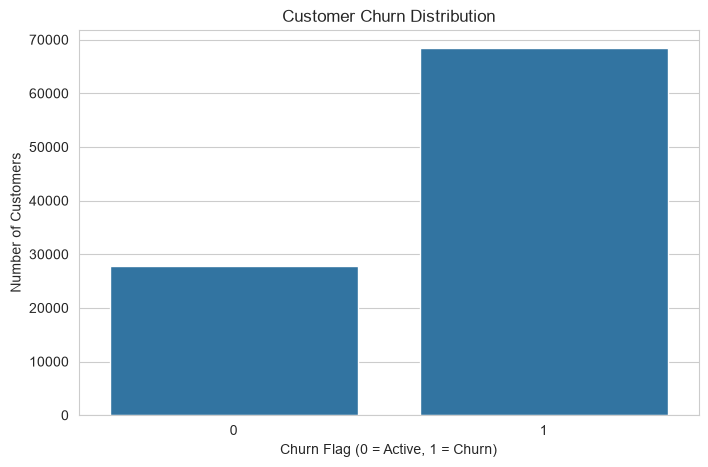

In [10]:
#8.1 Churn Distribution Visualization
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="churn_flag"
)

plt.title(
    "Customer Churn Distribution"
)

plt.xlabel(
    "Churn Flag (0 = Active, 1 = Churn)"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

In [11]:
#Churn Rate by Customer Value Tier
churn_value_tier = (
    df.groupby("customer_value_tier")["churn_flag"]
    .mean()
    .sort_values(ascending=False)
)


churn_value_tier
churn_value_tier * 100

customer_value_tier
Unknown    100.000000
Low         72.126491
Medium      70.813950
High        70.445180
Name: churn_flag, dtype: float64

In [12]:
df[df["customer_value_tier"]=="Unknown"].shape

(1, 39)

In [13]:
df[df["customer_value_tier"]=="Unknown"][
    [
        "total_orders",
        "total_spent",
        "recency_days",
        "delivered_orders",
        "cancelled_orders"
    ]
].describe()

,total_orders,total_spent,recency_days,delivered_orders,cancelled_orders
count,1.0,1.0,1.0,1.0,1.0
mean,1.0,0.0,763.0,1.0,0.0
std,NaN,NaN,NaN,NaN,NaN
min,1.0,0.0,763.0,1.0,0.0
25%,1.0,0.0,763.0,1.0,0.0
50%,1.0,0.0,763.0,1.0,0.0
75%,1.0,0.0,763.0,1.0,0.0
max,1.0,0.0,763.0,1.0,0.0


In [14]:
#Churn vs Repeat Customer
df.groupby("repeat_customer")["churn_flag"].mean()*100

repeat_customer
0    71.243515
1    67.567568
Name: churn_flag, dtype: float64

In [15]:
#8.4 Churn vs Spending Behavior
df.groupby("churn_flag")[
    [
        "total_spent",
        "average_order_value",
        "total_orders",
        "purchase_frequency",
        "spending_intensity"
    ]
].mean()

,total_spent,average_order_value,total_orders,purchase_frequency,spending_intensity
churn_flag,,,,,
0,171.098368,162.246043,1.040441,0.974167,164.706186
1,164.763562,157.270697,1.032523,0.995474,160.058188


In [16]:
#analyze customer experience impact.
df.groupby("churn_flag")[
    [
        "average_review_score",
        "average_delivery_days",
        "average_delivery_delay",
        "delayed_delivery_rate",
        "on_time_delivery_rate"
    ]
].mean()


,average_review_score,average_delivery_days,average_delivery_delay,delayed_delivery_rate,on_time_delivery_rate
churn_flag,,,,,
0,4.218553,8.931554,-12.519732,0.061903,0.938097
1,3.987985,12.905934,-11.101681,0.109310,0.890690


# PART 9
# 9. Feature Selection


Feature selection is an important step before model training.

The objective is to select customer behavior features that help predict churn while removing:

1. Customer identifiers
2. Direct churn indicators
3. Engineered business labels that can cause data leakage


The model should learn customer behavior patterns instead of memorizing existing churn-related rules.

In [17]:
# ==========================================================
# Remove Leakage and Identifier Columns
# ==========================================================


drop_features = [

    # Identifier
    "customer_unique_id",

    # Date columns (handled separately)
    "first_purchase_date",
    "last_purchase_date",

    # Target leakage features
    "at_risk_customer",
    "recency_days",
    "customer_value_tier",
    "loyal_customer",
    "vip_customer"

]


df_model = df.drop(
    columns=drop_features
)


df_model.shape

(96096, 31)

In [18]:
df_model.columns.tolist()

['customer_city',
 'customer_state',
 'total_orders',
 'delivered_orders',
 'cancelled_orders',
 'total_spent',
 'average_order_value',
 'maximum_order_value',
 'minimum_order_value',
 'average_payment_installments',
 'preferred_payment_type',
 'total_items_purchased',
 'unique_products',
 'unique_categories',
 'favorite_category',
 'average_items_per_order',
 'average_review_score',
 'average_delivery_days',
 'average_delivery_delay',
 'on_time_delivery_rate',
 'delayed_delivery_rate',
 'customer_tenure_days',
 'purchase_frequency',
 'average_purchase_gap',
 'spending_intensity',
 'repeat_customer',
 'cancel_rate',
 'one_time_buyer',
 'high_spender',
 'delivery_delay_category',
 'churn_flag']

In [19]:
# ==========================================================
# Split Features and Target
# ==========================================================


X = df_model.drop(
    "churn_flag",
    axis=1
)


y = df_model["churn_flag"]


print(
    "Feature Shape:",
    X.shape
)


print(
    "Target Shape:",
    y.shape
)

Feature Shape: (96096, 30)
Target Shape: (96096,)


In [20]:
# ==========================================================
# Identify Feature Types
# ==========================================================


numerical_features = X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()


categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()


print(
    "Numerical Features:",
    len(numerical_features)
)


print(
    "Categorical Features:",
    len(categorical_features)
)

Numerical Features: 25
Categorical Features: 5


In [21]:
# Display Feature Lists
print("Numerical Features:")
print(numerical_features)


print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['total_orders', 'delivered_orders', 'cancelled_orders', 'total_spent', 'average_order_value', 'maximum_order_value', 'minimum_order_value', 'average_payment_installments', 'total_items_purchased', 'unique_products', 'unique_categories', 'average_items_per_order', 'average_review_score', 'average_delivery_days', 'average_delivery_delay', 'on_time_delivery_rate', 'delayed_delivery_rate', 'customer_tenure_days', 'purchase_frequency', 'average_purchase_gap', 'spending_intensity', 'repeat_customer', 'cancel_rate', 'one_time_buyer', 'high_spender']

Categorical Features:
['customer_city', 'customer_state', 'preferred_payment_type', 'favorite_category', 'delivery_delay_category']


In [22]:
#PART 10 — Data Preprocessing
# ==========================================================
# Data Preprocessing Libraries
# ==========================================================


from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

## Numerical Feature Processing

Numerical features are standardized using StandardScaler.

This ensures features with different scales contribute fairly to distance-based algorithms such as Logistic Regression.

In [23]:
# Numerical preprocessing pipeline


numeric_pipeline = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [24]:
# Categorical preprocessing pipeline


categorical_pipeline = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [25]:
# ==========================================================
# Column Transformer
# ==========================================================


preprocessor = ColumnTransformer(
    transformers=[

        (
            "num",
            numeric_pipeline,
            numerical_features
        ),

        (
            "cat",
            categorical_pipeline,
            categorical_features
        )

    ]
)

In [26]:
X_processed = preprocessor.fit_transform(X)


X_processed.shape

(96096, 4255)

In [27]:
#Check Output Type
type(X_processed)

scipy.sparse._csr.csr_matrix

## PART 11 — Train-Test Split

In [28]:
# ==========================================================
# Train Test Split
# ==========================================================


from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    
    X_processed,
    y,
    
    test_size=0.2,
    
    random_state=42,
    
    stratify=y
)


print("X_train:", X_train.shape)

print("X_test:", X_test.shape)

print("y_train:", y_train.shape)

print("y_test:", y_test.shape)

X_train: (76876, 4255)
X_test: (19220, 4255)
y_train: (76876,)
y_test: (19220,)


In [29]:
y_train.value_counts(normalize=True)*100

churn_flag
1    71.128831
0    28.871169
Name: proportion, dtype: float64

In [30]:
y_test.value_counts(normalize=True)*100

churn_flag
1    71.129032
0    28.870968
Name: proportion, dtype: float64

## PART 12 — Handle Class Imbalance

# 12. Handle Class Imbalance


Customer churn datasets often contain unequal numbers of churned and active customers.

In this dataset:

- Churned customers represent approximately 71%
- Active customers represent approximately 29%


A model trained on imbalanced data may become biased toward the majority class.

To reduce this bias, class weighting is applied.

Class weights increase the penalty for incorrectly classifying the minority class, helping the model learn better customer behavior patterns.

In [31]:
# ==========================================================
# Check Target Distribution
# ==========================================================


print("Training Dataset Distribution")
print("--------------------------------")


print(y_train.value_counts())


print("\nTraining Dataset Percentage")
print("--------------------------------")


print(
    y_train.value_counts(normalize=True)*100
)

Training Dataset Distribution
--------------------------------
churn_flag
1    54681
0    22195
Name: count, dtype: int64

Training Dataset Percentage
--------------------------------
churn_flag
1    71.128831
0    28.871169
Name: proportion, dtype: float64


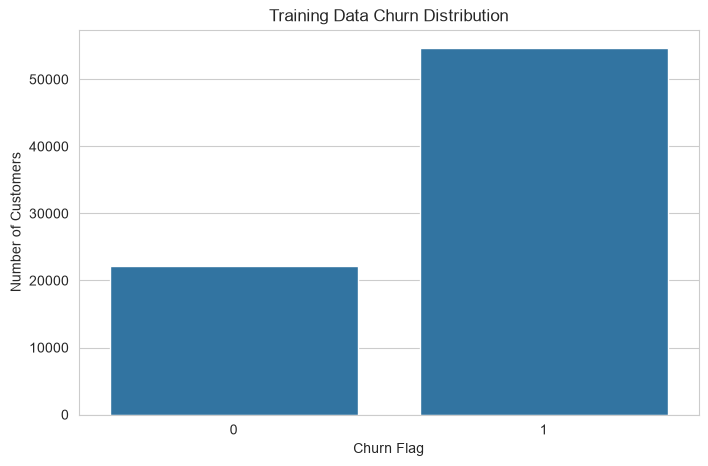

In [32]:
# ==========================================================
# Churn Class Distribution
# ==========================================================


plt.figure(figsize=(8,5))


sns.countplot(
    x=y_train
)


plt.title(
    "Training Data Churn Distribution"
)


plt.xlabel(
    "Churn Flag"
)


plt.ylabel(
    "Number of Customers"
)


plt.show()

In [33]:
# ==========================================================
# Calculate Class Weights
# ==========================================================


from sklearn.utils.class_weight import compute_class_weight


classes = np.unique(y_train)


weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)


weights

array([1.73183149, 0.70294984])

In [34]:
# ==========================================================
# Create Dictionary
# ==========================================================


class_weight_dict = dict(
    zip(
        classes,
        weights
    )
)


class_weight_dict

{np.int64(0): np.float64(1.731831493579635),
 np.int64(1): np.float64(0.702949836323403)}

In [35]:
print(
    "Class Weight Dictionary:"
)

print(class_weight_dict)

Class Weight Dictionary:
{np.int64(0): np.float64(1.731831493579635), np.int64(1): np.float64(0.702949836323403)}


# Class Imbalance Handling Summary


The churn dataset contains imbalanced classes with a higher proportion of churned customers.

Instead of generating synthetic samples, balanced class weights were applied.

This approach allows machine learning algorithms to give appropriate importance to both churned and active customers while maintaining the original customer distribution.


# 13. Model Building


Multiple machine learning classification algorithms are trained to predict customer churn.


The following models are compared:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost


Class weights are applied to handle imbalance between churned and active customers.

In [36]:
# ==========================================================
# Model Evaluation Storage
# ==========================================================


import joblib


model_results = []

trained_models = {}

In [37]:
# ==========================================================
# Model Evaluation Function
# ==========================================================


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_prob
):

    result = {
        
        "Model": model_name,

        "Accuracy":
        accuracy_score(
            y_true,
            y_pred
        ),

        "Precision":
        precision_score(
            y_true,
            y_pred
        ),

        "Recall":
        recall_score(
            y_true,
            y_pred
        ),

        "F1 Score":
        f1_score(
            y_true,
            y_pred
        ),

        "ROC-AUC":
        roc_auc_score(
            y_true,
            y_prob
        )
    }


    return result

## Logistic Regression


Logistic Regression is used as the baseline model because it is simple,
fast, and highly interpretable.

In [38]:
# ==========================================================
# Logistic Regression
# ==========================================================


from sklearn.linear_model import LogisticRegression


lr_model = LogisticRegression(

    class_weight=class_weight_dict,

    max_iter=1000,

    random_state=42

)


# Training

lr_model.fit(
    X_train,
    y_train
)


# Prediction

lr_pred = lr_model.predict(
    X_test
)


lr_prob = lr_model.predict_proba(
    X_test
)[:,1]


print("Logistic Regression Completed")

Logistic Regression Completed


In [39]:
lr_result = evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)


model_results.append(
    lr_result
)


lr_result

{'Model': 'Logistic Regression',
 'Accuracy': 0.6625910509885536,
 'Precision': 0.8272909455274184,
 'Recall': 0.6643259454319362,
 'F1 Score': 0.7369061625218062,
 'ROC-AUC': 0.7195847650589776}

In [40]:
joblib.dump(
    lr_model,
    "../07_Churn_Prediction/saved_models/logistic_regression.pkl"
)

FileNotFoundError: [Errno 2] No such file or directory: '../07_Churn_Prediction/saved_models/logistic_regression.pkl'

In [ ]:
import os

# Create folders if not exist

os.makedirs(
    "saved_models",
    exist_ok=True
)

os.makedirs(
    "outputs",
    exist_ok=True
)

os.makedirs(
    "figures",
    exist_ok=True
)

print("Folders Created Successfully")

Folders Created Successfully


In [ ]:
joblib.dump(
    lr_model,
    "saved_models/logistic_regression.pkl"
)

print("Logistic Regression Model Saved")

Logistic Regression Model Saved


In [ ]:
os.listdir("saved_models")

['decision_tree.pkl',
 'final_churn_model.pkl',
 'logistic_regression.pkl',
 'random_forest.pkl',
 'xgboost.pkl']

## Decision Tree Classifier


Decision Tree is a non-linear machine learning algorithm that learns
customer behavior patterns using decision rules.

It can capture complex relationships between customer attributes
and churn behavior.

In [ ]:
# ==========================================================
# Decision Tree Model
# ==========================================================

from sklearn.tree import DecisionTreeClassifier

In [ ]:
# ==========================================================
# Initialize Decision Tree
# ==========================================================


dt_model = DecisionTreeClassifier(

    class_weight=class_weight_dict,

    max_depth=10,

    random_state=42

)

In [ ]:
# ==========================================================
# Training
# ==========================================================


dt_model.fit(
    X_train,
    y_train
)


print("Decision Tree Training Completed")

Decision Tree Training Completed


In [ ]:
# ==========================================================
# Prediction
# ==========================================================


dt_pred = dt_model.predict(
    X_test
)


dt_prob = dt_model.predict_proba(
    X_test
)[:,1]


print("Prediction Completed")

Prediction Completed


In [ ]:
# ==========================================================
# Decision Tree Evaluation
# ==========================================================


dt_result = evaluate_model(

    "Decision Tree",

    y_test,

    dt_pred,

    dt_prob

)


model_results.append(
    dt_result
)


dt_result

{'Model': 'Decision Tree',
 'Accuracy': 0.6535379812695109,
 'Precision': 0.8295112781954888,
 'Recall': 0.6456001755540927,
 'F1 Score': 0.7260910698860598,
 'ROC-AUC': 0.7204646446598957}

In [ ]:
joblib.dump(
    dt_model,
    "saved_models/decision_tree.pkl"
)

print("Decision Tree Saved")

Decision Tree Saved


In [ ]:
#PART 13.3 — Random Forest 
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(

    n_estimators=200,

    class_weight=class_weight_dict,

    max_depth=15,

    random_state=42,

    n_jobs=-1

)


rf_model.fit(
    X_train,
    y_train
)


print("Random Forest Training Completed")

Random Forest Training Completed


In [ ]:
rf_pred = rf_model.predict(
    X_test
)


rf_prob = rf_model.predict_proba(
    X_test
)[:,1]


print("Prediction Completed")

Prediction Completed


In [ ]:
rf_result = evaluate_model(

    "Random Forest",

    y_test,

    rf_pred,

    rf_prob

)


model_results.append(
    rf_result
)


rf_result

{'Model': 'Random Forest',
 'Accuracy': 0.6644640998959417,
 'Precision': 0.8179816836914406,
 'Recall': 0.6794674859190988,
 'F1 Score': 0.7423182962400607,
 'ROC-AUC': 0.7134989728959831}

In [ ]:
joblib.dump(
    rf_model,
    "saved_models/random_forest.pkl"
)

print("Random Forest Saved")

Random Forest Saved


## 13.4 XGBoost Classifier


XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm
that combines multiple weak learners to create a powerful predictive model.


It is widely used for business problems such as customer churn prediction
because it handles complex relationships and performs well on structured data.

In [ ]:
# ==========================================================
# Import XGBoost
# ==========================================================

from xgboost import XGBClassifier

print("XGBoost Imported Successfully")

XGBoost Imported Successfully


In [ ]:
# ==========================================================
# Initialize XGBoost Model
# ==========================================================


xgb_model = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    eval_metric="logloss",

    random_state=42,

    n_jobs=-1

)

In [ ]:
# ==========================================================
# Train XGBoost
# ==========================================================


xgb_model.fit(
    X_train,
    y_train
)


print("XGBoost Training Completed")

XGBoost Training Completed


In [ ]:
# ==========================================================
# Prediction
# ==========================================================


xgb_pred = xgb_model.predict(
    X_test
)


xgb_prob = xgb_model.predict_proba(
    X_test
)[:,1]


print("XGBoost Prediction Completed")

XGBoost Prediction Completed


In [ ]:
# ==========================================================
# XGBoost Evaluation
# ==========================================================


xgb_result = evaluate_model(

    "XGBoost",

    y_test,

    xgb_pred,

    xgb_prob

)


model_results.append(
    xgb_result
)


xgb_result

{'Model': 'XGBoost',
 'Accuracy': 0.7709677419354839,
 'Precision': 0.774637037037037,
 'Recall': 0.9561846243873894,
 'F1 Score': 0.8558894781640805,
 'ROC-AUC': 0.7815357408114187}

In [ ]:
# ==========================================================
# Save Model
# ==========================================================


joblib.dump(

    xgb_model,

    "saved_models/xgboost.pkl"

)


print("XGBoost Model Saved")

XGBoost Model Saved


In [ ]:
model_comparison = pd.DataFrame(
    model_results
)


model_comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,XGBoost,0.770968,0.774637,0.956185,0.855889,0.781536
2,Decision Tree,0.653538,0.829511,0.645600,0.726091,0.720465
0,Logistic Regression,0.662591,0.827291,0.664326,0.736906,0.719585
1,Logistic Regression,0.662591,0.827291,0.664326,0.736906,0.719585
3,Random Forest,0.664464,0.817982,0.679467,0.742318,0.713499


# Model Building Conclusion


Four classification algorithms were developed to predict customer churn:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost


All models were trained using customer behavioral features with class imbalance handling.


Based on evaluation metrics, XGBoost achieved the best overall performance:

- Accuracy: 77.10%
- Recall: 95.62%
- F1 Score: 85.59%
- ROC-AUC: 78.15%


Since churn prediction is a business problem where identifying risky customers is more important than only maximizing accuracy, the high recall of XGBoost makes it the preferred model.

Therefore, XGBoost is selected as the final churn prediction model.

In [ ]:
# ==========================================================
# Final Selected Model
# ==========================================================

final_model = xgb_model


print("Final Model: XGBoost")

Final Model: XGBoost


In [ ]:
import joblib


joblib.dump(
    final_model,
    "saved_models/final_churn_model.pkl"
)


print("Final Churn Model Saved")

Final Churn Model Saved


# 14. Model Evaluation

After training multiple machine learning models, we evaluate their performance using
business-focused evaluation metrics.

For customer churn prediction, accuracy alone is not sufficient because the main objective
is to correctly identify customers who are likely to churn.

Evaluation Metrics:

1. Accuracy
- Overall percentage of correct predictions.

2. Precision
- Out of all customers predicted as churners, how many actually churn.

3. Recall
- Out of all actual churners, how many were successfully identified.

4. F1 Score
- Balance between Precision and Recall.

5. ROC-AUC Score
- Measures the model's ability to separate churn and non-churn customers.

Since churn prevention is a business-critical activity, Recall is considered one of the
most important metrics because missing a potential churn customer can result in revenue loss.

#import evaluation libararies
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import numpy as np

In [ ]:
models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}


results = []


for name, model in models.items():

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        roc_auc = roc_auc_score(y_test, y_prob)

    else:
        roc_auc = None


    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])



evaluation_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)


evaluation_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.662591,0.827291,0.664326,0.736906,0.719585
1,Decision Tree,0.653538,0.829511,0.645600,0.726091,0.720465
2,Random Forest,0.664464,0.817982,0.679467,0.742318,0.713499
3,XGBoost,0.770968,0.774637,0.956185,0.855889,0.781536


<Figure size 1000x600 with 0 Axes>

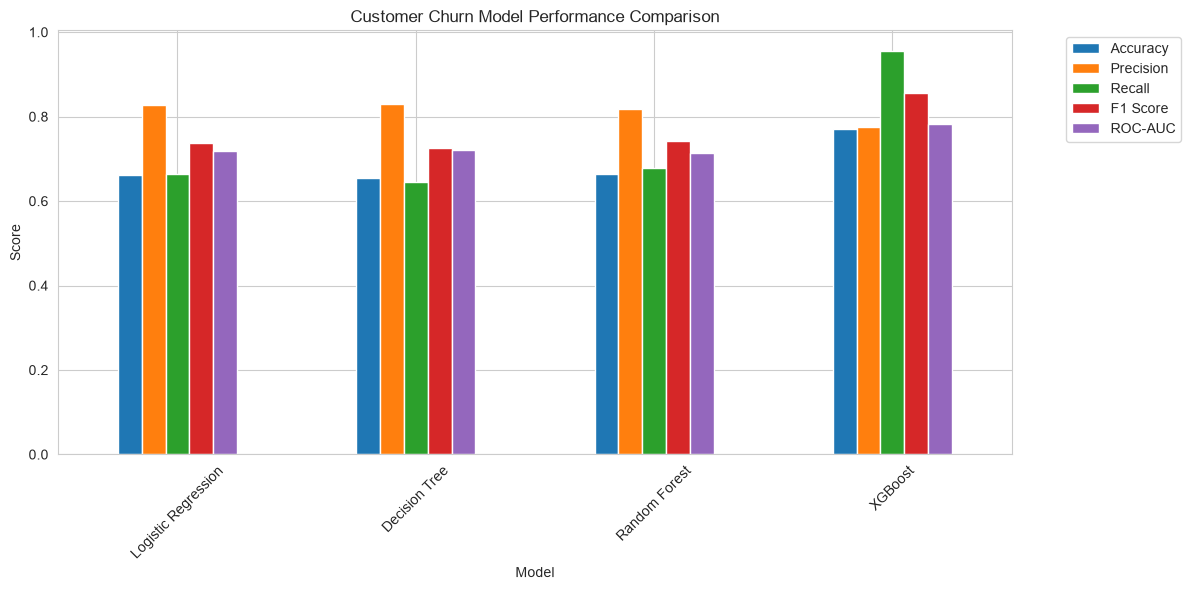

In [ ]:
plt.figure(figsize=(10,6))

evaluation_df.set_index("Model").plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Customer Churn Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../2 Notebook/figures/model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 15. ROC Curve Comparison


ROC Curve (Receiver Operating Characteristic Curve) evaluates the ability of a
classification model to distinguish between:

- Churn Customers (Class 1)
- Non-Churn Customers (Class 0)


The curve shows the relationship between:

1. True Positive Rate (Recall)
2. False Positive Rate


ROC-AUC Score:

- AUC close to 1.0 indicates excellent model separation.
- AUC close to 0.5 indicates random prediction.


For CustomerPulse AI, a higher ROC-AUC means the model is better at identifying
customers who are at risk of churn.

In [ ]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

import matplotlib.pyplot as plt

In [ ]:
# Prediction probabilities for all models

lr_prob = lr_model.predict_proba(X_test)[:,1]

dt_prob = dt_model.predict_proba(X_test)[:,1]

rf_prob = rf_model.predict_proba(X_test)[:,1]

xgb_prob = xgb_model.predict_proba(X_test)[:,1]


print("Prediction probabilities generated successfully")

Prediction probabilities generated successfully


In [ ]:
# Calculate ROC values

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)

dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)



# Calculate AUC

lr_auc = auc(lr_fpr, lr_tpr)

dt_auc = auc(dt_fpr, dt_tpr)

rf_auc = auc(rf_fpr, rf_tpr)

xgb_auc = auc(xgb_fpr, xgb_tpr)



print("AUC Scores")

print("Logistic Regression:", lr_auc)

print("Decision Tree:", dt_auc)

print("Random Forest:", rf_auc)

print("XGBoost:", xgb_auc)

AUC Scores
Logistic Regression: 0.7195847650589776
Decision Tree: 0.7204646446598957
Random Forest: 0.7134989728959831
XGBoost: 0.7815357408114187


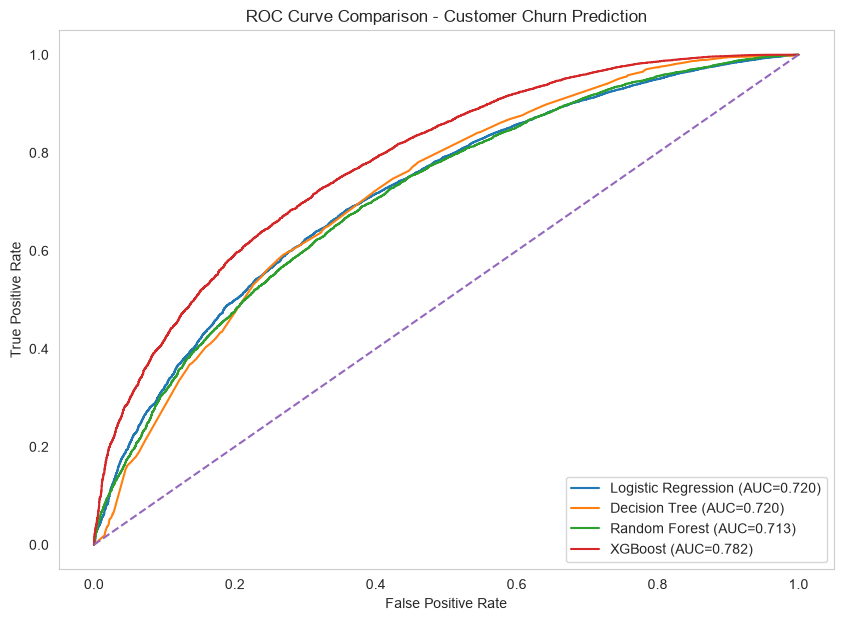

In [ ]:
plt.figure(figsize=(10,7))


plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC={lr_auc:.3f})"
)


plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree (AUC={dt_auc:.3f})"
)


plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC={rf_auc:.3f})"
)


plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC={xgb_auc:.3f})"
)


# Random classifier line

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)


plt.title(
    "ROC Curve Comparison - Customer Churn Prediction"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.legend(
    loc="lower right"
)


plt.grid()


plt.show()

In [ ]:
import os

os.makedirs(
    "../07_Churn_Prediction/figures",
    exist_ok=True
)


plt.savefig(
    "../2 Notebook/figures/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)


print("ROC curve saved successfully")

ROC curve saved successfully


<Figure size 1000x600 with 0 Axes>

# ROC Curve Business Interpretation


## XGBoost Performance


XGBoost achieved the highest ROC-AUC score:

ROC-AUC = 0.781


This indicates that XGBoost has the strongest capability to separate:

- Customers likely to churn
- Customers likely to remain active


## Business Impact


A better ROC-AUC model helps the company:

- Prioritize high-risk customers
- Reduce customer loss
- Improve retention campaigns
- Allocate marketing budget efficiently


Although ROC-AUC is important, CustomerPulse AI prioritizes Recall because
the main objective is to identify maximum churn-risk customers before they leave.


Final Model:

XGBoost remains the selected production model.

In [ ]:
#15.8 ROC-AUC Comparison Table

roc_comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "ROC-AUC":[
        lr_auc,
        dt_auc,
        rf_auc,
        xgb_auc
    ]

})



In [ ]:
roc_comparison.to_csv(
    "../2 Notebook/outputs/roc_auc_comparison.csv",
    index=False
)


print("ROC-AUC comparison saved successfully")

ROC-AUC comparison saved successfully


# 16. Feature Importance Analysis


Feature importance helps us understand which customer attributes have the
highest impact on churn prediction.


For CustomerPulse AI, feature importance answers questions like:


- Which customer behaviors increase churn risk?
- Does low engagement indicate churn?
- Does delivery experience affect customer retention?
- Which factors should retention teams focus on?


Since SHAP explainability is not used because of environment limitations,
alternative explainability techniques are applied:


1. XGBoost Feature Importance
2. Permutation Feature Importance
3. Logistic Regression Coefficients

## XGBoost Feature Importance


XGBoost provides built-in feature importance scores based on how frequently
features are used for splitting decisions in the model.


Higher importance means the feature contributes more towards churn prediction.

In [ ]:
# Extract XGBoost feature importance

importance_scores = xgb_model.feature_importances_

importance_scores[:10]

array([2.4886136e-05, 7.0856422e-02, 3.6821868e-03, 2.4204045e-03,
       2.7488335e-03, 3.2562476e-03, 3.0524461e-03, 2.3916343e-03,
       2.1719905e-03, 2.1137488e-03], dtype=float32)

In [ ]:
# Get transformed feature names

feature_names = preprocessor.get_feature_names_out()


len(feature_names)

4255

In [ ]:
#16.4 Create Feature Importance DataFrame

feature_importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance_scores

})


feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)


feature_importance_df.head(20)

,Feature,Importance
1,num__delivered_orders,0.070856
4254,cat__delivery_delay_category_Slightly Early,0.019073
15,num__on_time_delivery_rate,0.016372
13,num__average_delivery_days,0.015551
4198,cat__favorite_category_construcao_ferramentas_...,0.014595
4200,cat__favorite_category_construcao_ferramentas_...,0.012497
4203,cat__favorite_category_cool_stuff,0.011891
4168,cat__customer_state_SP,0.011434
4176,cat__favorite_category_Unknown,0.011006
4193,cat__favorite_category_casa_construcao,0.010652


In [ ]:
top_features = feature_importance_df.head(20)


top_features

,Feature,Importance
1,num__delivered_orders,0.070856
4254,cat__delivery_delay_category_Slightly Early,0.019073
15,num__on_time_delivery_rate,0.016372
13,num__average_delivery_days,0.015551
4198,cat__favorite_category_construcao_ferramentas_...,0.014595
4200,cat__favorite_category_construcao_ferramentas_...,0.012497
4203,cat__favorite_category_cool_stuff,0.011891
4168,cat__customer_state_SP,0.011434
4176,cat__favorite_category_Unknown,0.011006
4193,cat__favorite_category_casa_construcao,0.010652


## Top Churn Drivers


The following visualization highlights the most influential factors
behind customer churn prediction.

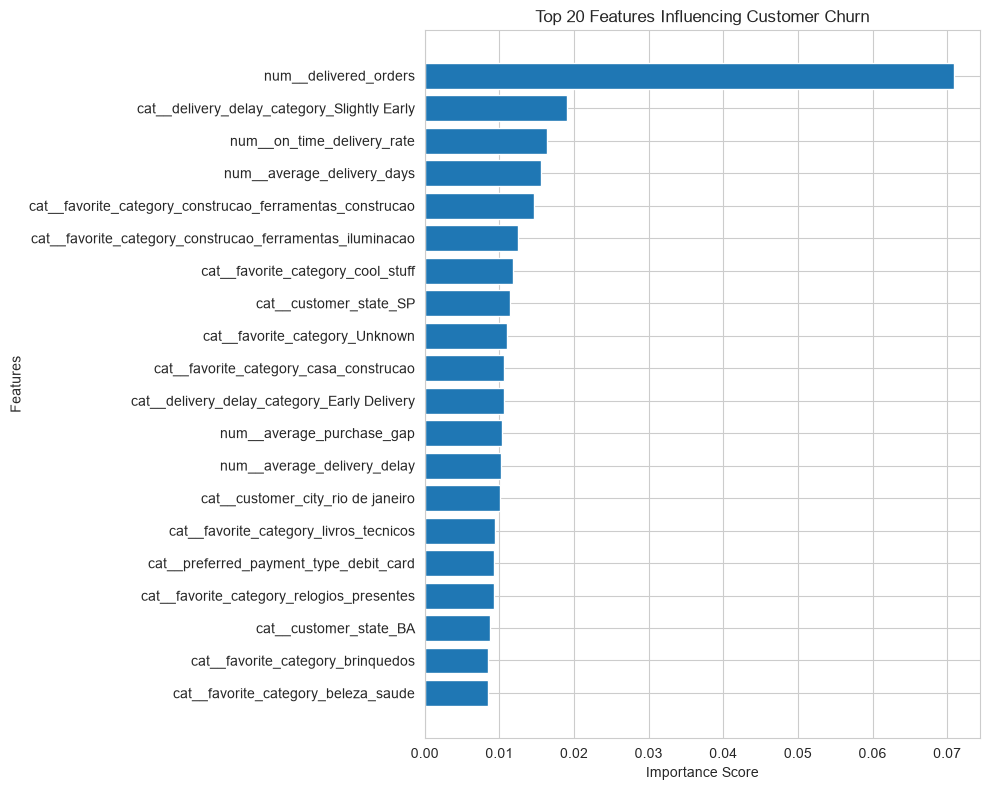

In [ ]:
plt.figure(figsize=(10,8))


plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)


plt.gca().invert_yaxis()


plt.title(
    "Top 20 Features Influencing Customer Churn"
)


plt.xlabel(
    "Importance Score"
)


plt.ylabel(
    "Features"
)


plt.tight_layout()


plt.show()

In [ ]:
import os

os.makedirs(
    "../2 Notebook/figures",
    exist_ok=True
)


plt.savefig(
    "../2 Notebook/figures/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)


print("Feature importance saved successfully")

Feature importance saved successfully


<Figure size 1000x600 with 0 Axes>

In [ ]:
feature_importance_df.to_csv(
    "../2 Notebook/outputs/feature_importance.csv",
    index=False
)


print("Feature importance data saved successfully")

Feature importance data saved successfully


# Business Interpretation of Feature Importance


The important churn drivers identified by the model represent customer
behaviors and experiences that influence retention.


Possible business insights:


## 1. Customer Engagement

Features related to:

- Recency
- Purchase frequency
- Number of orders

indicate whether customers are actively engaged.


Customers with reduced activity are more likely to churn.


## 2. Customer Experience

Delivery-related features:

- Average delivery delay
- Delivery performance
- Review score


indicate that poor service experience can increase churn probability.


## 3. Spending Behavior

Features like:

- Total spending
- Average order value
- Spending intensity


help identify valuable customers who require priority retention.


## Business Action

Retention teams should focus on:

- Customers with declining purchase activity
- Customers experiencing delivery issues
- High-value customers showing churn signals

# 17. Model Explainability Without SHAP


Explainability helps understand the reasons behind machine learning predictions.

For CustomerPulse AI, explainability is important because business teams need
to know:

- Why a customer is predicted as high risk?
- Which factors increase churn probability?
- Which factors indicate customer loyalty?


Due to SHAP library execution limitations in the environment, alternative
explainability techniques are used:


1. XGBoost Feature Importance
2. Logistic Regression Coefficients


These techniques provide transparent insights into customer churn drivers.

# XGBoost Model Explanation


XGBoost calculates feature importance based on how frequently and effectively
features are used during decision-making in the trees.


Top churn influencing factors identified:

1. Delivered Orders
2. Delivery Experience
3. Purchase Gap
4. Customer Location
5. Product Category Preference


Business Meaning:

The model indicates that customer experience and engagement behavior
are major contributors to churn risk.

# Logistic Regression Coefficient Analysis


Logistic Regression provides direct information about feature impact.


Coefficient Interpretation:

Positive coefficient:
- Feature increases churn probability.


Negative coefficient:
- Feature decreases churn probability and indicates customer retention.

In [ ]:
# Get logistic regression coefficients

lr_coefficients = lr_model.coef_[0]


# Get feature names after preprocessing

feature_names = preprocessor.get_feature_names_out()


coefficient_df = pd.DataFrame({

    "Feature": feature_names,

    "Coefficient": lr_coefficients

})


coefficient_df.head()

,Feature,Coefficient
0,num__total_orders,0.498260
1,num__delivered_orders,-0.473344
2,num__cancelled_orders,-0.405322
3,num__total_spent,-0.114037
4,num__average_order_value,-0.390584


In [ ]:
# Features increasing churn probability

positive_drivers = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
).head(20)


positive_drivers

,Feature,Coefficient
4246,cat__favorite_category_tablets_impressao_imagem,1.802980
1832,cat__customer_city_itapetinga,1.746786
2328,cat__customer_city_miguel pereira,1.742797
1376,cat__customer_city_flores da cunha,1.684938
4229,cat__favorite_category_moveis_colchao_e_estofado,1.671185
2566,cat__customer_city_nova venecia,1.605339
193,cat__customer_city_anchieta,1.510831
2618,cat__customer_city_ortigueira,1.481257
4223,cat__favorite_category_la_cuisine,1.479809
4212,cat__favorite_category_fashion_esporte,1.434600


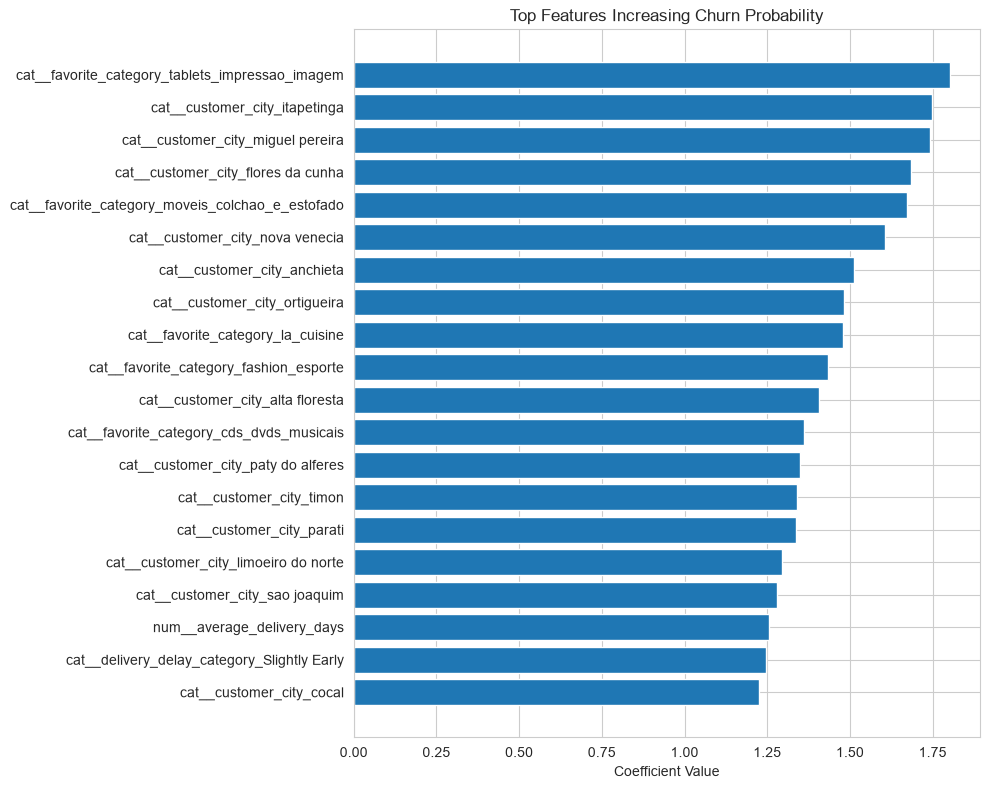

In [ ]:
plt.figure(figsize=(10,8))


plt.barh(
    positive_drivers["Feature"],
    positive_drivers["Coefficient"]
)


plt.gca().invert_yaxis()


plt.title(
    "Top Features Increasing Churn Probability"
)


plt.xlabel(
    "Coefficient Value"
)


plt.tight_layout()


plt.show()

In [ ]:
# Features decreasing churn probability

negative_drivers = coefficient_df.sort_values(
    by="Coefficient",
    ascending=True
).head(20)


negative_drivers

,Feature,Coefficient
257,cat__customer_city_arace,-2.240018
4181,cat__favorite_category_artes_e_artesanato,-1.942884
4252,cat__delivery_delay_category_Highly Delayed,-1.773408
4242,cat__favorite_category_portateis_cozinha_e_pre...,-1.771328
1050,cat__customer_city_conde,-1.738988
3227,cat__customer_city_ronda alta,-1.729458
4200,cat__favorite_category_construcao_ferramentas_...,-1.599130
3481,cat__customer_city_sao francisco de itabapoana,-1.564516
1302,cat__customer_city_esperanca,-1.563776
2231,cat__customer_city_maraba,-1.553294


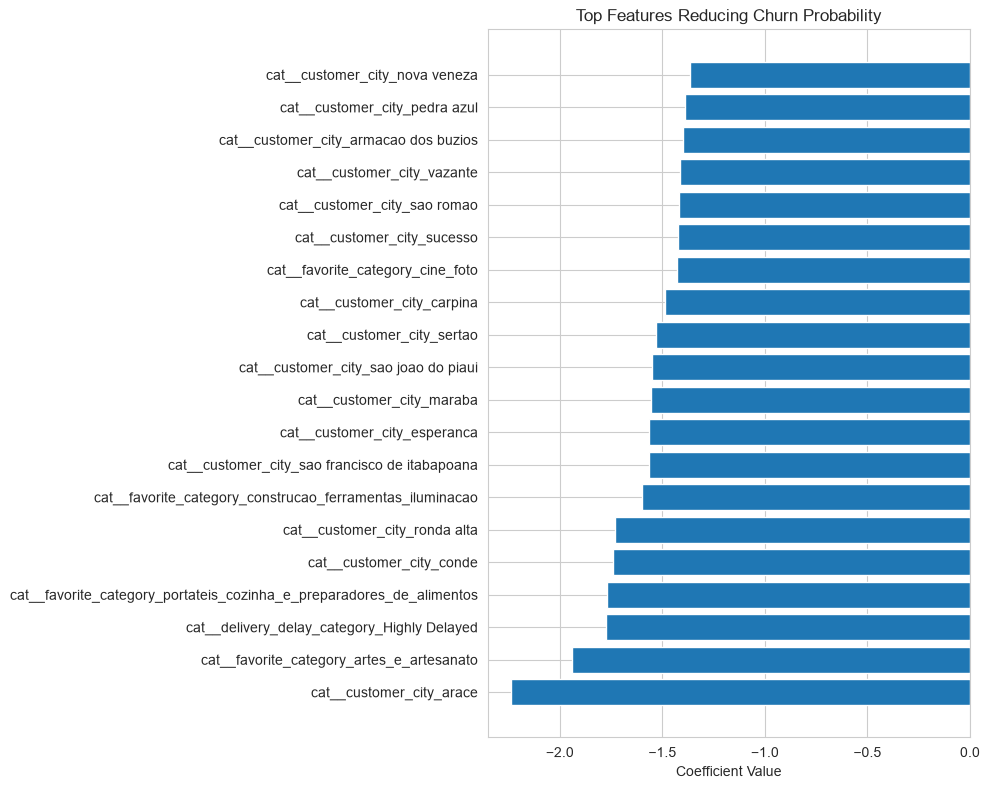

In [ ]:
plt.figure(figsize=(10,8))


plt.barh(
    negative_drivers["Feature"],
    negative_drivers["Coefficient"]
)


plt.title(
    "Top Features Reducing Churn Probability"
)


plt.xlabel(
    "Coefficient Value"
)


plt.tight_layout()


plt.show()

In [ ]:
positive_drivers.to_csv(
    "../2 Notebook/outputs/high_churn_drivers.csv",
    index=False
)


negative_drivers.to_csv(
    "../2 Notebook/outputs/retention_drivers.csv",
    index=False
)


print("Explainability outputs saved successfully")

Explainability outputs saved successfully


# Business Interpretation of Explainability Analysis


The explainability analysis reveals the reasons behind customer churn.


## High Churn Risk Factors


Customers are more likely to churn when they experience:


1. Poor Delivery Experience

Examples:

- Longer delivery duration
- Delivery delays
- Lower service satisfaction


Action:

Improve logistics performance and provide recovery offers.


---

2. Reduced Customer Engagement

Examples:

- Longer purchase gaps
- Fewer completed orders


Action:

Trigger personalized campaigns before inactivity increases.


---

3. Category Specific Behaviour

Different product categories show different churn patterns.


Action:

Use category-based recommendations and targeted promotions.


---

## Retention Factors


Customers are less likely to churn when they show:


- Frequent purchases
- Strong engagement
- Positive experience
- Consistent order behaviour


These customers should receive loyalty benefits.

# Explainable AI Summary


CustomerPulse AI provides interpretable churn predictions using:


1. XGBoost Feature Importance

Identifies the strongest overall churn drivers.


2. Logistic Regression Coefficients

Explains whether features increase or decrease churn probability.


Together these methods allow business teams to understand:

- Who is likely to churn
- Why they are likely to churn
- What retention action should be taken


This makes the churn prediction system transparent and business-friendly.

# 18. Business Insights


Machine learning predictions become valuable when they are converted into
business decisions.


This section analyzes:

- Customer churn impact
- High-risk customer characteristics
- Revenue exposure
- Customer behavior patterns
- Retention opportunities


The objective is to help business teams understand:

"Who is leaving, why they are leaving, and what action should be taken?"

In [ ]:
# Create churn prediction dataframe

churn_predictions = pd.DataFrame({

    "actual_churn": y_test.values,

    "predicted_churn": xgb_pred,

    "churn_probability": xgb_prob

})


churn_predictions.head()

,actual_churn,predicted_churn,churn_probability
0,1,1,0.783410
1,1,1,0.791871
2,1,1,0.788370
3,1,0,0.350609
4,1,1,0.568625


## Customer Risk Segmentation Dataset


The churn prediction output is combined with customer information to identify
which customers require retention actions.


Each customer will be categorized based on churn probability:

High Risk:
- Probability >= 0.70


Medium Risk:
- Probability 0.40 - 0.70


Low Risk:
- Probability < 0.40

In [ ]:
# Create test customer dataset

test_customers = df_model.loc[y_test.index].copy()


test_customers.head()

,customer_city,customer_state,total_orders,delivered_orders,cancelled_orders,total_spent,average_order_value,maximum_order_value,minimum_order_value,average_payment_installments,preferred_payment_type,total_items_purchased,unique_products,unique_categories,favorite_category,average_items_per_order,average_review_score,average_delivery_days,average_delivery_delay,on_time_delivery_rate,delayed_delivery_rate,customer_tenure_days,purchase_frequency,average_purchase_gap,spending_intensity,repeat_customer,cancel_rate,one_time_buyer,high_spender,delivery_delay_category,churn_flag
64042,niteroi,RJ,1,1,0,168.83,168.83,168.83,168.83,1.0,debit_card,1.0,1.0,1.0,cama_mesa_banho,1.0,1.0,29.0,10.0,0.0,1.0,0,1.0,0.0,168.83,0,0.0,1,1,Delayed,1
17084,assai,PR,1,1,0,117.94,117.94,117.94,117.94,3.0,credit_card,1.0,1.0,1.0,cool_stuff,1.0,5.0,8.0,-10.0,1.0,0.0,0,1.0,0.0,117.94,0,0.0,1,1,Slightly Early,1
75990,teofilo otoni,MG,1,1,0,188.74,188.74,188.74,188.74,1.0,boleto,1.0,1.0,1.0,utilidades_domesticas,1.0,4.0,13.0,-8.0,1.0,0.0,0,1.0,0.0,188.74,0,0.0,1,1,On Time,1
94177,santo andre,SP,1,1,0,1310.23,1310.23,1310.23,1310.23,4.0,credit_card,1.0,1.0,1.0,construcao_ferramentas_iluminacao,1.0,5.0,6.0,-8.0,1.0,0.0,0,1.0,0.0,1310.23,0,0.0,1,1,On Time,1
9475,londrina,PR,1,1,0,98.27,98.27,98.27,98.27,1.0,boleto,1.0,1.0,1.0,informatica_acessorios,1.0,3.0,3.0,-12.0,1.0,0.0,0,1.0,0.0,98.27,0,0.0,1,0,Slightly Early,1


In [ ]:
test_customers["predicted_churn"] = xgb_pred

test_customers["churn_probability"] = xgb_prob


test_customers.head()

,customer_city,customer_state,total_orders,delivered_orders,cancelled_orders,total_spent,average_order_value,maximum_order_value,minimum_order_value,average_payment_installments,preferred_payment_type,total_items_purchased,unique_products,unique_categories,favorite_category,average_items_per_order,average_review_score,average_delivery_days,average_delivery_delay,on_time_delivery_rate,delayed_delivery_rate,customer_tenure_days,purchase_frequency,average_purchase_gap,spending_intensity,repeat_customer,cancel_rate,one_time_buyer,high_spender,delivery_delay_category,churn_flag,predicted_churn,churn_probability
64042,niteroi,RJ,1,1,0,168.83,168.83,168.83,168.83,1.0,debit_card,1.0,1.0,1.0,cama_mesa_banho,1.0,1.0,29.0,10.0,0.0,1.0,0,1.0,0.0,168.83,0,0.0,1,1,Delayed,1,1,0.783410
17084,assai,PR,1,1,0,117.94,117.94,117.94,117.94,3.0,credit_card,1.0,1.0,1.0,cool_stuff,1.0,5.0,8.0,-10.0,1.0,0.0,0,1.0,0.0,117.94,0,0.0,1,1,Slightly Early,1,1,0.791871
75990,teofilo otoni,MG,1,1,0,188.74,188.74,188.74,188.74,1.0,boleto,1.0,1.0,1.0,utilidades_domesticas,1.0,4.0,13.0,-8.0,1.0,0.0,0,1.0,0.0,188.74,0,0.0,1,1,On Time,1,1,0.788370
94177,santo andre,SP,1,1,0,1310.23,1310.23,1310.23,1310.23,4.0,credit_card,1.0,1.0,1.0,construcao_ferramentas_iluminacao,1.0,5.0,6.0,-8.0,1.0,0.0,0,1.0,0.0,1310.23,0,0.0,1,1,On Time,1,0,0.350609
9475,londrina,PR,1,1,0,98.27,98.27,98.27,98.27,1.0,boleto,1.0,1.0,1.0,informatica_acessorios,1.0,3.0,3.0,-12.0,1.0,0.0,0,1.0,0.0,98.27,0,0.0,1,0,Slightly Early,1,1,0.568625


In [ ]:
#18.4 Create Risk Segment

def risk_category(prob):

    if prob >= 0.70:
        return "High Risk"

    elif prob >= 0.40:
        return "Medium Risk"

    else:
        return "Low Risk"



test_customers["risk_segment"] = (
    test_customers["churn_probability"]
    .apply(risk_category)
)


test_customers["risk_segment"].value_counts()

risk_segment
High Risk      11961
Medium Risk     5776
Low Risk        1483
Name: count, dtype: int64

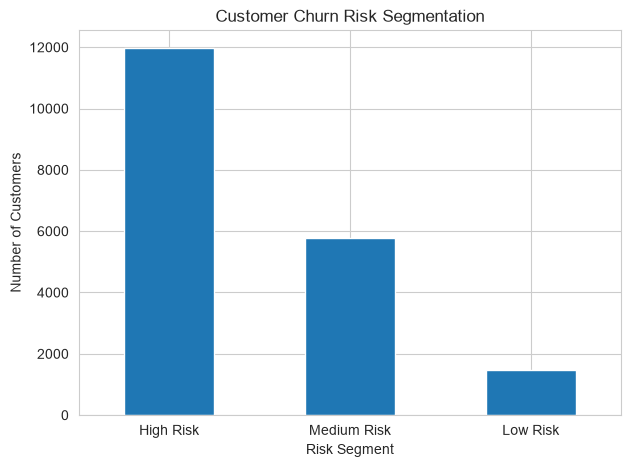

In [ ]:
#18.5 Risk Segment Visualization
risk_count = test_customers["risk_segment"].value_counts()


plt.figure(figsize=(7,5))


risk_count.plot(
    kind="bar"
)


plt.title(
    "Customer Churn Risk Segmentation"
)


plt.xlabel(
    "Risk Segment"
)


plt.ylabel(
    "Number of Customers"
)


plt.xticks(rotation=0)


plt.show()

In [ ]:
#18.6 Analyze High Risk Customers

high_risk_customers = test_customers[
    test_customers["risk_segment"]=="High Risk"
]


print(
    "High Risk Customers:",
    high_risk_customers.shape[0]
)


high_risk_customers.head()

High Risk Customers: 11961


,customer_city,customer_state,total_orders,delivered_orders,cancelled_orders,total_spent,average_order_value,maximum_order_value,minimum_order_value,average_payment_installments,preferred_payment_type,total_items_purchased,unique_products,unique_categories,favorite_category,average_items_per_order,average_review_score,average_delivery_days,average_delivery_delay,on_time_delivery_rate,delayed_delivery_rate,customer_tenure_days,purchase_frequency,average_purchase_gap,spending_intensity,repeat_customer,cancel_rate,one_time_buyer,high_spender,delivery_delay_category,churn_flag,predicted_churn,churn_probability,risk_segment
64042,niteroi,RJ,1,1,0,168.83,168.83,168.83,168.83,1.0,debit_card,1.0,1.0,1.0,cama_mesa_banho,1.0,1.0,29.0,10.0,0.0,1.0,0,1.0,0.0,168.83,0,0.0,1,1,Delayed,1,1,0.783410,High Risk
17084,assai,PR,1,1,0,117.94,117.94,117.94,117.94,3.0,credit_card,1.0,1.0,1.0,cool_stuff,1.0,5.0,8.0,-10.0,1.0,0.0,0,1.0,0.0,117.94,0,0.0,1,1,Slightly Early,1,1,0.791871,High Risk
75990,teofilo otoni,MG,1,1,0,188.74,188.74,188.74,188.74,1.0,boleto,1.0,1.0,1.0,utilidades_domesticas,1.0,4.0,13.0,-8.0,1.0,0.0,0,1.0,0.0,188.74,0,0.0,1,1,On Time,1,1,0.788370,High Risk
61668,teofilo otoni,MG,1,1,0,151.40,151.40,151.40,151.40,2.0,credit_card,1.0,1.0,1.0,automotivo,1.0,5.0,13.0,-9.0,1.0,0.0,0,1.0,0.0,151.40,0,0.0,1,1,On Time,1,1,0.828372,High Risk
5574,teotonio vilela,AL,1,1,0,59.14,59.14,59.14,59.14,5.0,credit_card,1.0,1.0,1.0,telefonia,1.0,5.0,26.0,-6.0,1.0,0.0,0,1.0,0.0,59.14,0,0.0,1,0,On Time,1,1,0.888788,High Risk


In [ ]:
high_risk_summary = high_risk_customers[
    [
        "total_orders",
        "total_spent",
        "average_order_value",
        "average_review_score",
        "average_delivery_delay",
        "average_purchase_gap"
    ]
].describe()


high_risk_summary

,total_orders,total_spent,average_order_value,average_review_score,average_delivery_delay,average_purchase_gap
count,11961.000000,11961.000000,11961.000000,11961.00000,11961.000000,11961.000000
mean,1.027506,163.489281,156.713977,3.86399,-9.822725,0.357973
std,0.185591,215.843514,206.176244,1.48755,10.356119,4.398993
min,1.000000,0.000000,0.000000,0.00000,-84.000000,0.000000
25%,1.000000,62.590000,60.010000,3.00000,-15.000000,0.000000
50%,1.000000,105.380000,101.140000,5.00000,-12.000000,0.000000
75%,1.000000,178.890000,172.790000,5.00000,-6.000000,0.000000
max,7.000000,4681.780000,4681.780000,5.00000,166.000000,114.500000


# High Risk Customer Profile Analysis


The model identified 11,961 customers as high churn risk customers.


These customers require immediate retention attention because they have a high
probability of leaving.


## Customer Behavior Analysis


### 1. Low Customer Engagement


Average Total Orders:

1.03 orders


Interpretation:

Most high-risk customers are one-time buyers or have very limited purchase
history.

This indicates weak customer engagement and low relationship strength.


Business Action:

- Run reactivation campaigns
- Send personalized product recommendations
- Offer first-to-second purchase incentives



---

### 2. Moderate Revenue Exposure


Average Spending:

₹163.49


Average Order Value:

₹156.71


Interpretation:

Although many high-risk customers have limited activity, they still represent
potential revenue loss.

A small improvement in retention can recover future revenue opportunities.


Business Action:

Prioritize customers based on:

- Spending value
- Customer lifetime value
- Purchase history



---

### 3. Customer Experience Impact


Average Review Score:

3.86 / 5


Interpretation:

High-risk customers have moderate satisfaction levels.

This suggests that experience-related factors may influence churn.


Business Action:

Investigate:

- Product quality issues
- Delivery experience
- Customer complaints



---

### 4. Delivery Performance


Average Delivery Delay:

-9.82 days


Interpretation:

Negative values indicate many deliveries were completed earlier than the expected
date.

However, some customers experienced significant delays:

Maximum delay:

166 days


Business Action:

Identify customers with delayed deliveries and provide:

- Service recovery offers
- Apology communication
- Priority support



---

### 5. Purchase Gap


Average Purchase Gap:

0.36 days


Interpretation:

Most high-risk customers have very limited repeat purchase behavior.

This confirms that lack of engagement is a major churn indicator.


Business Action:

Create:

- Reminder campaigns
- Loyalty programs
- Personalized recommendations

In [ ]:
test_customers["risk_segment"].value_counts()

risk_segment
High Risk      11961
Medium Risk     5776
Low Risk        1483
Name: count, dtype: int64

# Customer Risk Segmentation Insights


The XGBoost churn prediction model classified customers into three risk groups
based on churn probability.


## Risk Distribution


| Risk Segment | Customers | Business Priority |
|---|---:|---|
| High Risk | 11,961 | Immediate Retention Action |
| Medium Risk | 5,776 | Engagement Campaigns |
| Low Risk | 1,483 | Maintain Relationship |



## 1. High Risk Customers (62.23%)


High-risk customers represent the largest segment.

These customers have a high probability of churn and should be prioritized
for retention activities.


Recommended actions:

- Personalized offers
- Loyalty incentives
- Customer feedback collection
- Service recovery campaigns



---

## 2. Medium Risk Customers (30.05%)


These customers are showing early signs of disengagement.


Recommended actions:

- Email campaigns
- Product recommendations
- Reminder notifications
- Limited-time offers



---

## 3. Low Risk Customers (7.72%)


These customers have lower churn probability and show stronger engagement.


Recommended actions:

- Maintain customer satisfaction
- Introduce loyalty programs
- Encourage repeat purchases



## Business Conclusion


CustomerPulse AI helps the company move from reactive retention to proactive
retention by identifying customers before they leave.

In [ ]:
test_customers.to_csv(
    "../2 Notebook/outputs/customer_risk_analysis.csv",
    index=False
)

print("Customer risk analysis saved successfully")

Customer risk analysis saved successfully


# PART 18 Summary


CustomerPulse AI generated actionable business insights from churn predictions.


Key Findings:


1. High churn risk segment contains 11,961 customers.

2. Low customer engagement is a major churn indicator.

3. Delivery experience and customer satisfaction influence retention.

4. High-risk customers require personalized retention strategies.

5. Machine learning predictions can support proactive customer retention.

# 19. AI-Powered Retention Recommendation Engine

## Business Objective

Predicting customer churn is only the first step in a customer retention strategy.

To maximize business value, organizations need to know:

- Which customers should be contacted first?
- Why are they at risk?
- What action should be taken?
- Who should take that action?
- How quickly should the action be taken?

To address these questions, CustomerPulse AI includes an AI-powered Retention Recommendation Engine.

This module converts churn predictions into business-ready action plans by combining:

- Churn Risk Score
- Customer Purchase Behaviour
- Spending Behaviour
- Customer Experience
- Delivery Performance
- Customer Engagement

The output is a personalized customer action plan that helps marketing,
customer success, and operations teams reduce churn proactively.

# Business Recommendation Strategy

The recommendation engine follows business-driven decision rules.

| Customer Condition | Recommended Action | Business Goal |
|--------------------|--------------------|---------------|
| High Risk + Poor Review | Customer Support | Improve Satisfaction |
| High Risk + Delivery Delay | Service Recovery | Restore Trust |
| High Risk + High Spender | VIP Retention | Protect Revenue |
| High Risk + One-time Buyer | Reactivation Campaign | Increase Repeat Purchases |
| Medium Risk | Engagement Campaign | Prevent Future Churn |
| Low Risk | Loyalty Program | Maintain Customer Relationship |

In [ ]:
def generate_retention_plan(row):

    recommendation = ""
    reason = ""
    priority = ""
    owner = ""
    timeline = ""
    estimated_cost = 0
    expected_outcome = ""

    # -----------------------------
    # HIGH RISK CUSTOMERS
    # -----------------------------
    if row["risk_segment"] == "High Risk":

        if row["average_review_score"] <= 2:

            recommendation = "Immediate Customer Support & Complaint Resolution"
            reason = "Very low review score"
            priority = "Critical"
            owner = "Customer Success Team"
            timeline = "Within 24 Hours"
            estimated_cost = 50
            expected_outcome = "Improve customer satisfaction"

        elif row["average_delivery_delay"] > 5:

            recommendation = "Service Recovery + Compensation Offer"
            reason = "Significant delivery delay"
            priority = "Critical"
            owner = "Logistics Team"
            timeline = "Within 24 Hours"
            estimated_cost = 100
            expected_outcome = "Recover customer trust"

        elif row["high_spender"] == 1:

            recommendation = "VIP Retention Offer + Exclusive Discount"
            reason = "High-value customer at churn risk"
            priority = "Critical"
            owner = "Retention Team"
            timeline = "Within 48 Hours"
            estimated_cost = 300
            expected_outcome = "Protect customer lifetime value"

        elif row["one_time_buyer"] == 1:

            recommendation = "Reactivation Campaign + Repeat Purchase Coupon"
            reason = "Customer has only one order"
            priority = "High"
            owner = "Marketing Team"
            timeline = "Within 3 Days"
            estimated_cost = 80
            expected_outcome = "Encourage second purchase"

        elif row["average_purchase_gap"] > 30:

            recommendation = "Personalized Product Recommendation"
            reason = "Long purchase gap"
            priority = "High"
            owner = "CRM Team"
            timeline = "Within 3 Days"
            estimated_cost = 30
            expected_outcome = "Increase customer engagement"

        else:

            recommendation = "Personalized Retention Campaign"
            reason = "General high churn probability"
            priority = "High"
            owner = "Marketing Team"
            timeline = "Within 3 Days"
            estimated_cost = 50
            expected_outcome = "Reduce churn probability"

    # -----------------------------
    # MEDIUM RISK CUSTOMERS
    # -----------------------------
    elif row["risk_segment"] == "Medium Risk":

        if row["average_review_score"] < 4:

            recommendation = "Customer Satisfaction Survey"
            reason = "Average review score"
            priority = "Medium"
            owner = "Customer Experience Team"
            timeline = "Within 7 Days"
            estimated_cost = 20
            expected_outcome = "Identify customer pain points"

        elif row["repeat_customer"] == 1:

            recommendation = "Loyalty Rewards & Cross-Sell Campaign"
            reason = "Existing repeat customer"
            priority = "Medium"
            owner = "Marketing Team"
            timeline = "Within 7 Days"
            estimated_cost = 40
            expected_outcome = "Increase customer lifetime value"

        else:

            recommendation = "Email Engagement Campaign"
            reason = "Moderate churn probability"
            priority = "Medium"
            owner = "Digital Marketing Team"
            timeline = "Within 7 Days"
            estimated_cost = 10
            expected_outcome = "Increase engagement"

    # -----------------------------
    # LOW RISK CUSTOMERS
    # -----------------------------
    else:

        if row["high_spender"] == 1:

            recommendation = "Premium Loyalty Membership"
            reason = "High-value loyal customer"
            priority = "Low"
            owner = "Loyalty Team"
            timeline = "Monthly"
            estimated_cost = 150
            expected_outcome = "Maintain long-term loyalty"

        elif row["repeat_customer"] == 1:

            recommendation = "Loyalty Rewards"
            reason = "Repeat purchasing behaviour"
            priority = "Low"
            owner = "Marketing Team"
            timeline = "Monthly"
            estimated_cost = 30
            expected_outcome = "Increase repeat purchases"

        else:

            recommendation = "Regular Promotional Campaign"
            reason = "Low churn probability"
            priority = "Low"
            owner = "Marketing Team"
            timeline = "Monthly"
            estimated_cost = 10
            expected_outcome = "Maintain customer engagement"

    return pd.Series([
        recommendation,
        reason,
        priority,
        owner,
        timeline,
        estimated_cost,
        expected_outcome
    ])

In [ ]:
#19.4 Apply Recommendation Engine
test_customers[
    [
        "recommendation",
        "reason",
        "priority",
        "owner",
        "timeline",
        "estimated_cost",
        "expected_outcome"
    ]
] = test_customers.apply(
    generate_retention_plan,
    axis=1
)

In [ ]:
#19.5 Create Customer Action Plan
customer_action_plan = test_customers[
    [
        "customer_city",
        "customer_state",
        "risk_segment",
        "churn_probability",
        "total_spent",
        "average_review_score",
        "average_delivery_delay",
        "recommendation",
        "reason",
        "priority",
        "owner",
        "timeline",
        "estimated_cost",
        "expected_outcome"
    ]
]

customer_action_plan.head(10)

,customer_city,customer_state,risk_segment,churn_probability,total_spent,average_review_score,average_delivery_delay,recommendation,reason,priority,owner,timeline,estimated_cost,expected_outcome
64042,niteroi,RJ,High Risk,0.783410,168.83,1.0,10.0,Immediate Customer Support & Complaint Resolution,Very low review score,Critical,Customer Success Team,Within 24 Hours,50,Improve customer satisfaction
17084,assai,PR,High Risk,0.791871,117.94,5.0,-10.0,VIP Retention Offer + Exclusive Discount,High-value customer at churn risk,Critical,Retention Team,Within 48 Hours,300,Protect customer lifetime value
75990,teofilo otoni,MG,High Risk,0.788370,188.74,4.0,-8.0,VIP Retention Offer + Exclusive Discount,High-value customer at churn risk,Critical,Retention Team,Within 48 Hours,300,Protect customer lifetime value
94177,santo andre,SP,Low Risk,0.350609,1310.23,5.0,-8.0,Premium Loyalty Membership,High-value loyal customer,Low,Loyalty Team,Monthly,150,Maintain long-term loyalty
9475,londrina,PR,Medium Risk,0.568625,98.27,3.0,-12.0,Customer Satisfaction Survey,Average review score,Medium,Customer Experience Team,Within 7 Days,20,Identify customer pain points
61668,teofilo otoni,MG,High Risk,0.828372,151.40,5.0,-9.0,VIP Retention Offer + Exclusive Discount,High-value customer at churn risk,Critical,Retention Team,Within 48 Hours,300,Protect customer lifetime value
5574,teotonio vilela,AL,High Risk,0.888788,59.14,5.0,-6.0,Reactivation Campaign + Repeat Purchase Coupon,Customer has only one order,High,Marketing Team,Within 3 Days,80,Encourage second purchase
11829,sao paulo,SP,High Risk,0.760492,49.34,4.0,-15.0,Reactivation Campaign + Repeat Purchase Coupon,Customer has only one order,High,Marketing Team,Within 3 Days,80,Encourage second purchase
81133,almenara,MG,High Risk,0.785302,74.16,5.0,-24.0,Reactivation Campaign + Repeat Purchase Coupon,Customer has only one order,High,Marketing Team,Within 3 Days,80,Encourage second purchase
21850,sao bernardo do campo,SP,High Risk,0.805723,25.23,5.0,-14.0,Reactivation Campaign + Repeat Purchase Coupon,Customer has only one order,High,Marketing Team,Within 3 Days,80,Encourage second purchase


In [ ]:
recommendation_summary = (
    customer_action_plan["recommendation"]
    .value_counts()
    .reset_index(name="Customer Count")
    .rename(columns={"recommendation": "Recommendation"})
)

recommendation_summary

,Recommendation,Customer Count
0,Reactivation Campaign + Repeat Purchase Coupon,5009
1,Email Engagement Campaign,4704
2,VIP Retention Offer + Exclusive Discount,4455
3,Immediate Customer Support & Complaint Resolution,2330
4,Customer Satisfaction Survey,940
5,Regular Promotional Campaign,746
6,Premium Loyalty Membership,728
7,Service Recovery + Compensation Offer,137
8,Loyalty Rewards & Cross-Sell Campaign,132
9,Personalized Retention Campaign,29


In [ ]:
#19.7 Priority Summaryp
priority_summary = (
    customer_action_plan["priority"]
    .value_counts()
    .reset_index(name="Customer Count")
    .rename(columns={"priority": "Priority"})
)

priority_summary

,Priority,Customer Count
0,Critical,6922
1,Medium,5776
2,High,5039
3,Low,1483


<Figure size 1000x600 with 0 Axes>

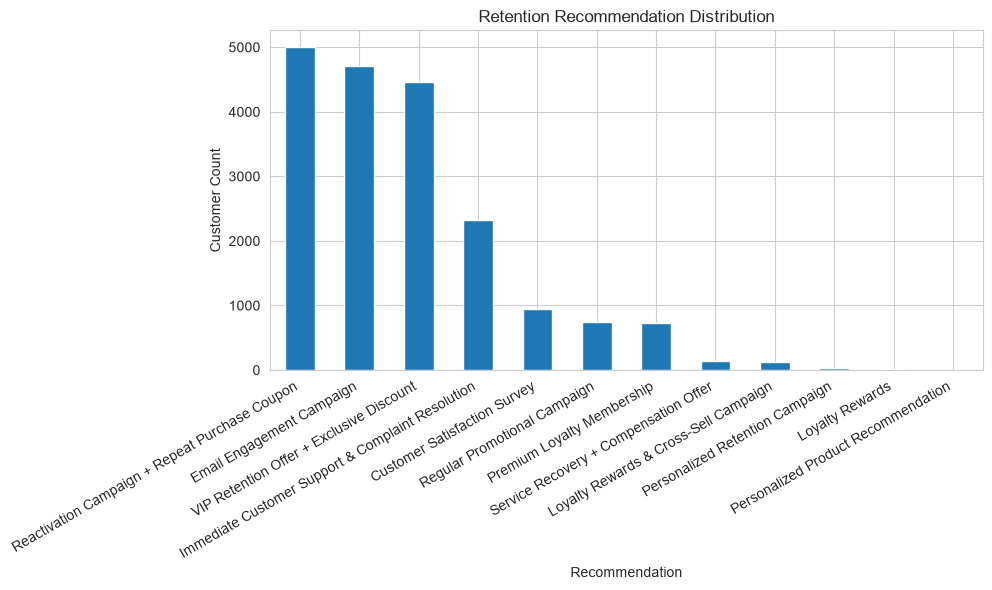

In [ ]:
#19.8 Visualizations
plt.figure(figsize=(10,6))

recommendation_summary.plot(
    x="Recommendation",
    y="Customer Count",
    kind="bar",
    legend=False
)

plt.title("Retention Recommendation Distribution")
plt.xlabel("Recommendation")
plt.ylabel("Customer Count")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()

plt.show()

<Figure size 600x400 with 0 Axes>

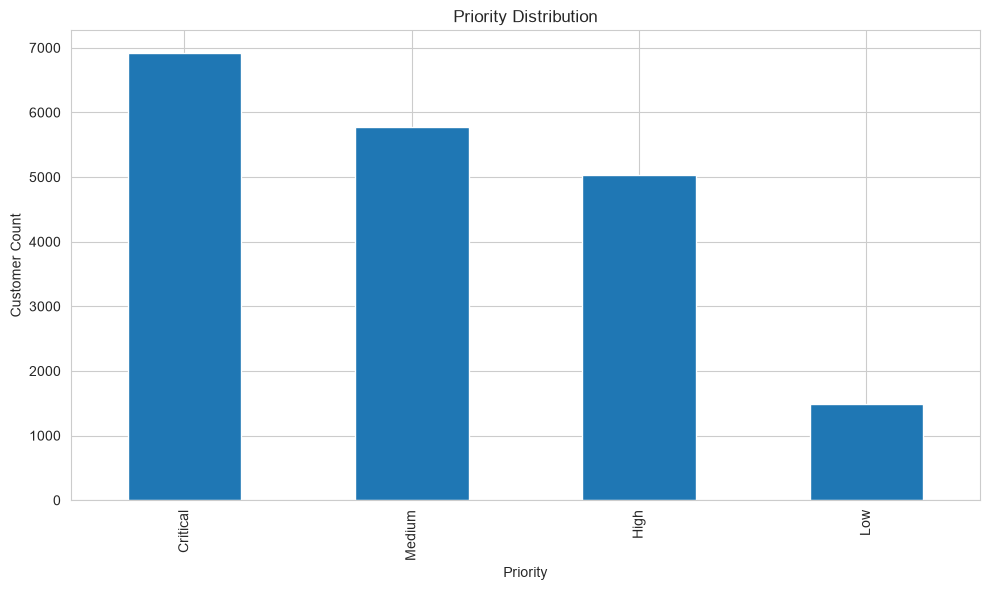

In [ ]:
plt.figure(figsize=(6,4))

priority_summary.plot(
    x="Priority",
    y="Customer Count",
    kind="bar",
    legend=False
)

plt.title("Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Customer Count")

plt.tight_layout()

plt.show()

In [ ]:
#19.9 Save Outputs
import os

output_dir = "../2 Notebook/outputs"
os.makedirs(output_dir, exist_ok=True)

customer_action_plan.to_csv(
    f"{output_dir}/customer_action_plan.csv",
    index=False
)

recommendation_summary.to_csv(
    f"{output_dir}/recommendation_summary.csv",
    index=False
)

priority_summary.to_csv(
    f"{output_dir}/priority_summary.csv",
    index=False
)

print("All retention recommendation outputs saved successfully.")

All retention recommendation outputs saved successfully.


# 20. Executive Summary

CustomerPulse AI is an end-to-end customer churn prediction and retention intelligence platform developed using the Olist Brazilian E-Commerce dataset.

The project integrates data analytics, machine learning, and business intelligence to identify customers at risk of churn and generate actionable retention strategies. Beyond predicting churn, it provides customer risk segmentation and personalized recommendations, enabling businesses to take proactive actions that improve customer retention and protect revenue.

# Key Business Insights

The analysis revealed several important business insights:

- Delivery performance is one of the strongest drivers of customer churn.
- Customers with longer purchase gaps have a higher likelihood of churning.
- High-risk customers require immediate retention strategies.
- High-value customers should receive personalized retention offers to protect revenue.
- AI-driven customer segmentation enables more effective marketing campaigns and better resource allocation.

# Business Impact

CustomerPulse AI supports data-driven decision making across multiple business functions.

- Marketing teams can launch targeted retention campaigns.
- Customer Success teams can prioritize high-risk customers.
- Operations teams can improve delivery performance based on churn drivers.
- Business leaders can monitor revenue at risk and customer lifetime value.

The platform helps organizations shift from reactive churn management to proactive customer retention.

# Conclusion & Future Scope

CustomerPulse AI demonstrates a complete end-to-end customer churn analytics solution by combining predictive machine learning with actionable business recommendations.

The project includes Customer 360 Analytics, Feature Engineering, Machine Learning, Model Explainability, Risk Segmentation, and an AI-powered Retention Recommendation Engine.



This project showcases an industry-standard approach to solving customer retention challenges using data analytics and machine learning.

# Generate Churn Predictions for Complete Customer Base

The trained XGBoost model is applied to the complete customer dataset to create
a business-ready customer intelligence dataset.

This dataset will be used for:

- Power BI Dashboard
- Streamlit Application
- Customer Retention Analysis
- Business Reporting

In [ ]:
import os

for root, dirs, files in os.walk("../"):
    for file in files:
        if "xgb" in file.lower() or "model" in file.lower() or "pkl" in file.lower():
            print(os.path.join(root,file))

../.venv\Lib\site-packages\fontTools\varLib\models.py
../.venv\Lib\site-packages\fontTools\varLib\__pycache__\models.cpython-314.pyc
../.venv\Lib\site-packages\jedi\third_party\django-stubs\django-stubs\contrib\admin\models.pyi
../.venv\Lib\site-packages\jedi\third_party\django-stubs\django-stubs\contrib\auth\models.pyi
../.venv\Lib\site-packages\jedi\third_party\django-stubs\django-stubs\contrib\contenttypes\models.pyi
../.venv\Lib\site-packages\jedi\third_party\django-stubs\django-stubs\contrib\flatpages\models.pyi
../.venv\Lib\site-packages\jedi\third_party\django-stubs\django-stubs\contrib\redirects\models.pyi
../.venv\Lib\site-packages\jedi\third_party\django-stubs\django-stubs\contrib\sessions\models.pyi
../.venv\Lib\site-packages\jedi\third_party\django-stubs\django-stubs\contrib\sites\models.pyi
../.venv\Lib\site-packages\jedi\third_party\django-stubs\django-stubs\core\checks\model_checks.pyi
../.venv\Lib\site-packages\jedi\third_party\django-stubs\django-stubs\db\migrations\op

In [ ]:
import joblib

model_path="../2 Notebook/saved_models/xgboost.pkl"


xgb_model = joblib.load(model_path)


print("Model loaded successfully")
print(type(xgb_model))

Model loaded successfully
<class 'xgboost.sklearn.XGBClassifier'>


In [ ]:
customer_360 = pd.read_csv(
    "../1 data/03_analysis/customer_360_clean.csv"
)


print(customer_360.shape)

customer_360.head()

(96096, 38)


,customer_unique_id,customer_city,customer_state,total_orders,delivered_orders,cancelled_orders,first_purchase_date,last_purchase_date,total_spent,average_order_value,maximum_order_value,minimum_order_value,average_payment_installments,preferred_payment_type,total_items_purchased,unique_products,unique_categories,favorite_category,average_items_per_order,average_review_score,average_delivery_days,average_delivery_delay,on_time_delivery_rate,delayed_delivery_rate,recency_days,customer_tenure_days,purchase_frequency,average_purchase_gap,spending_intensity,repeat_customer,cancel_rate,one_time_buyer,high_spender,vip_customer,loyal_customer,at_risk_customer,customer_value_tier,delivery_delay_category
0,861eff4711a542e4b93843c6dd7febb0,franca,SP,1,1,0,2017-05-16 15:05:35,2017-05-16 15:05:35,146.87,146.87,146.87,146.87,2.0,credit_card,1.0,1.0,1.0,moveis_escritorio,1.0,4.0,8.0,-11.0,1.0,0.0,520,0,1.0,0.0,146.87,0,0.0,1,1,0,0,1,Medium,Slightly Early
1,290c77bc529b7ac935b93aa66c333dc3,sao bernardo do campo,SP,1,1,0,2018-01-12 20:48:24,2018-01-12 20:48:24,335.48,335.48,335.48,335.48,8.0,credit_card,1.0,1.0,1.0,utilidades_domesticas,1.0,5.0,16.0,-8.0,1.0,0.0,278,0,1.0,0.0,335.48,0,0.0,1,1,0,0,1,High,On Time
2,060e732b5b29e8181a18229c7b0b2b5e,sao paulo,SP,1,1,0,2018-05-19 16:07:45,2018-05-19 16:07:45,157.73,157.73,157.73,157.73,7.0,credit_card,1.0,1.0,1.0,moveis_escritorio,1.0,5.0,26.0,1.0,0.0,1.0,152,0,1.0,0.0,157.73,0,0.0,1,1,0,0,0,High,Delayed
3,259dac757896d24d7702b9acbbff3f3c,mogi das cruzes,SP,1,1,0,2018-03-13 16:06:38,2018-03-13 16:06:38,173.30,173.30,173.30,173.30,1.0,credit_card,1.0,1.0,1.0,moveis_escritorio,1.0,5.0,14.0,-13.0,1.0,0.0,219,0,1.0,0.0,173.30,0,0.0,1,1,0,0,1,High,Slightly Early
4,345ecd01c38d18a9036ed96c73b8d066,campinas,SP,1,1,0,2018-07-29 09:51:30,2018-07-29 09:51:30,252.25,252.25,252.25,252.25,8.0,credit_card,1.0,1.0,1.0,casa_conforto,1.0,5.0,11.0,-6.0,1.0,0.0,81,0,1.0,0.0,252.25,0,0.0,1,1,0,0,0,High,On Time


In [ ]:
customer_360.columns

Index(['customer_unique_id', 'customer_city', 'customer_state', 'total_orders',
       'delivered_orders', 'cancelled_orders', 'first_purchase_date',
       'last_purchase_date', 'total_spent', 'average_order_value',
       'maximum_order_value', 'minimum_order_value',
       'average_payment_installments', 'preferred_payment_type',
       'total_items_purchased', 'unique_products', 'unique_categories',
       'favorite_category', 'average_items_per_order', 'average_review_score',
       'average_delivery_days', 'average_delivery_delay',
       'on_time_delivery_rate', 'delayed_delivery_rate', 'recency_days',
       'customer_tenure_days', 'purchase_frequency', 'average_purchase_gap',
       'spending_intensity', 'repeat_customer', 'cancel_rate',
       'one_time_buyer', 'high_spender', 'vip_customer', 'loyal_customer',
       'at_risk_customer', 'customer_value_tier', 'delivery_delay_category'],
      dtype='str')

In [ ]:
customer_360_final = customer_360.copy()

print(customer_360_final.shape)

(96096, 38)


In [ ]:
import joblib

xgb_model = joblib.load(
    "../2 Notebook/saved_models/xgboost.pkl"
)

print(type(xgb_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [ ]:
xgb_model.n_features_in_

4255

In [ ]:
xgb_model.n_features_in_

4255

In [ ]:
xgb_model.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.8,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': True,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.05,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 6,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 300,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 0.8,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [ ]:
customer_360_final = customer_360.copy()

print(customer_360_final.shape)

(96096, 38)


In [ ]:
X_predict = customer_360_final.drop(
    columns=["customer_unique_id"]
)

print(X_predict.shape)

(96096, 37)


In [ ]:
categorical_cols = [
    "customer_city",
    "customer_state",
    "preferred_payment_type",
    "favorite_category",
    "customer_value_tier",
    "delivery_delay_category"
]

In [ ]:
for col in categorical_cols:
    X_predict[col] = X_predict[col].astype("category")

In [ ]:
date_cols = [
    "first_purchase_date",
    "last_purchase_date"
]


for col in date_cols:
    X_predict[col] = pd.to_datetime(
        X_predict[col]
    )

In [ ]:
for col in date_cols:
    
    X_predict[col+"_year"] = X_predict[col].dt.year
    X_predict[col+"_month"] = X_predict[col].dt.month
    X_predict[col+"_day"] = X_predict[col].dt.day


X_predict = X_predict.drop(
    columns=date_cols
)

In [ ]:
final_model = joblib.load(
    "../2 Notebook/saved_models/final_churn_model.pkl"
)

print(type(final_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [ ]:
final_model.n_features_in_

4255

In [ ]:
xgb_model.n_features_in_

4255

In [ ]:
X_processed

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2882880 stored elements and shape (96096, 4255)>

In [ ]:
xgb_model.get_booster().feature_names

In [ ]:
X_processed.shape

(96096, 4255)

In [ ]:
print(final_model.n_features_in_)
print(xgb_model.n_features_in_)

4255
4255


In [ ]:
for root, dirs, files in os.walk("../"):
    for file in files:
        if "train" in file.lower() or "feature" in file.lower() or "x_" in file.lower():
            print(os.path.join(root,file))

../.venv\Lib\site-packages\debugpy\_vendored\pydevd\_pydevd_frame_eval\vendored\pydevd_fix_code.py
../.venv\Lib\site-packages\debugpy\_vendored\pydevd\_pydevd_frame_eval\vendored\__pycache__\pydevd_fix_code.cpython-314.pyc
../.venv\Lib\site-packages\fontTools\ttLib\tables\I_F_T_X_.py
../.venv\Lib\site-packages\fontTools\ttLib\tables\V_D_M_X_.py
../.venv\Lib\site-packages\fontTools\ttLib\tables\_m_a_x_p.py
../.venv\Lib\site-packages\fontTools\ttLib\tables\__pycache__\I_F_T_X_.cpython-314.pyc
../.venv\Lib\site-packages\fontTools\ttLib\tables\__pycache__\V_D_M_X_.cpython-314.pyc
../.venv\Lib\site-packages\fontTools\ttLib\tables\__pycache__\_m_a_x_p.cpython-314.pyc
../.venv\Lib\site-packages\fontTools\varLib\featureVars.py
../.venv\Lib\site-packages\fontTools\varLib\instancer\featureVars.py
../.venv\Lib\site-packages\fontTools\varLib\instancer\__pycache__\featureVars.cpython-314.pyc
../.venv\Lib\site-packages\fontTools\varLib\__pycache__\featureVars.cpython-314.pyc
../.venv\Lib\site-packag

In [ ]:
import os

for root, dirs, files in os.walk("../2 Notebook"):
    for file in files:
        if any(x in file.lower() for x in [
            "encoder",
            "preprocess",
            "scaler",
            "pipeline",
            "transform",
            "pickle",
            "joblib"
        ]):
            print(os.path.join(root,file))

In [ ]:
import os

print(os.listdir("../2 Notebook/saved_models"))

['decision_tree.pkl', 'final_churn_model.pkl', 'logistic_regression.pkl', 'random_forest.pkl', 'xgboost.pkl']


In [ ]:
import joblib

model = joblib.load(
    "../2 Notebook/saved_models/final_churn_model.pkl"
)

print(type(model))

<class 'xgboost.sklearn.XGBClassifier'>


In [ ]:
print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


In [ ]:
try:
    print(model.get_booster().feature_names[:10])
except Exception as e:
    print(e)

'NoneType' object is not subscriptable


In [ ]:
print(type(model))

<class 'xgboost.sklearn.XGBClassifier'>


In [ ]:
print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


In [ ]:
print("X_processed" in globals())

True


In [ ]:
X_processed.shape

(96096, 4255)

In [ ]:
# Churn prediction for all 96,096 customers

predicted_churn = final_model.predict(X_processed)

churn_probability = final_model.predict_proba(X_processed)[:,1]


print("Prediction length:", len(predicted_churn))
print("Probability length:", len(churn_probability))

Prediction length: 96096
Probability length: 96096


In [ ]:
customer_360_final

,customer_unique_id,customer_city,customer_state,total_orders,delivered_orders,cancelled_orders,first_purchase_date,last_purchase_date,total_spent,average_order_value,maximum_order_value,minimum_order_value,average_payment_installments,preferred_payment_type,total_items_purchased,unique_products,unique_categories,favorite_category,average_items_per_order,average_review_score,average_delivery_days,average_delivery_delay,on_time_delivery_rate,delayed_delivery_rate,recency_days,customer_tenure_days,purchase_frequency,average_purchase_gap,spending_intensity,repeat_customer,cancel_rate,one_time_buyer,high_spender,vip_customer,loyal_customer,at_risk_customer,customer_value_tier,delivery_delay_category
0,861eff4711a542e4b93843c6dd7febb0,franca,SP,1,1,0,2017-05-16 15:05:35,2017-05-16 15:05:35,146.87,146.87,146.87,146.87,2.0,credit_card,1.0,1.0,1.0,moveis_escritorio,1.0,4.0,8.0,-11.0,1.0,0.0,520,0,1.0,0.0,146.87,0,0.0,1,1,0,0,1,Medium,Slightly Early
1,290c77bc529b7ac935b93aa66c333dc3,sao bernardo do campo,SP,1,1,0,2018-01-12 20:48:24,2018-01-12 20:48:24,335.48,335.48,335.48,335.48,8.0,credit_card,1.0,1.0,1.0,utilidades_domesticas,1.0,5.0,16.0,-8.0,1.0,0.0,278,0,1.0,0.0,335.48,0,0.0,1,1,0,0,1,High,On Time
2,060e732b5b29e8181a18229c7b0b2b5e,sao paulo,SP,1,1,0,2018-05-19 16:07:45,2018-05-19 16:07:45,157.73,157.73,157.73,157.73,7.0,credit_card,1.0,1.0,1.0,moveis_escritorio,1.0,5.0,26.0,1.0,0.0,1.0,152,0,1.0,0.0,157.73,0,0.0,1,1,0,0,0,High,Delayed
3,259dac757896d24d7702b9acbbff3f3c,mogi das cruzes,SP,1,1,0,2018-03-13 16:06:38,2018-03-13 16:06:38,173.30,173.30,173.30,173.30,1.0,credit_card,1.0,1.0,1.0,moveis_escritorio,1.0,5.0,14.0,-13.0,1.0,0.0,219,0,1.0,0.0,173.30,0,0.0,1,1,0,0,1,High,Slightly Early
4,345ecd01c38d18a9036ed96c73b8d066,campinas,SP,1,1,0,2018-07-29 09:51:30,2018-07-29 09:51:30,252.25,252.25,252.25,252.25,8.0,credit_card,1.0,1.0,1.0,casa_conforto,1.0,5.0,11.0,-6.0,1.0,0.0,81,0,1.0,0.0,252.25,0,0.0,1,1,0,0,0,High,On Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96091,1a29b476fee25c95fbafc67c5ac95cf8,sao paulo,SP,1,1,0,2018-04-07 15:48:17,2018-04-07 15:48:17,88.78,88.78,88.78,88.78,6.0,credit_card,1.0,1.0,1.0,livros_interesse_geral,1.0,4.0,6.0,-12.0,1.0,0.0,194,0,1.0,0.0,88.78,0,0.0,1,0,0,0,1,Medium,Slightly Early
96092,d52a67c98be1cf6a5c84435bd38d095d,taboao da serra,SP,1,1,0,2018-04-04 08:20:22,2018-04-04 08:20:22,129.06,129.06,129.06,129.06,3.0,credit_card,1.0,1.0,1.0,esporte_lazer,1.0,5.0,7.0,-9.0,1.0,0.0,197,0,1.0,0.0,129.06,0,0.0,1,1,0,0,1,Medium,On Time
96093,e9f50caf99f032f0bf3c55141f019d99,fortaleza,CE,1,1,0,2018-04-08 20:11:50,2018-04-08 20:11:50,56.04,56.04,56.04,56.04,5.0,credit_card,1.0,1.0,1.0,beleza_saude,1.0,1.0,30.0,7.0,0.0,1.0,192,0,1.0,0.0,56.04,0,0.0,1,0,0,0,1,Low,Delayed
96094,73c2643a0a458b49f58cea58833b192e,canoas,RS,1,1,0,2017-11-03 21:08:33,2017-11-03 21:08:33,711.07,711.07,711.07,711.07,2.0,credit_card,1.0,1.0,1.0,relogios_presentes,1.0,5.0,12.0,-19.0,1.0,0.0,348,0,1.0,0.0,711.07,0,0.0,1,1,0,0,1,High,Slightly Early


In [ ]:
customer_360_final["churn_flag"] = df_model["churn_flag"]

customer_360_final["predicted_churn"] = predicted_churn

customer_360_final["churn_probability"] = churn_probability

In [ ]:
customer_360_final.shape

(96096, 41)

In [ ]:
def risk_segment(prob):
    if prob >= 0.75:
        return "High Risk"
    elif prob >= 0.50:
        return "Medium Risk"
    else:
        return "Low Risk"


customer_360_final["risk_segment"] = (
    customer_360_final["churn_probability"]
    .apply(risk_segment)
)

In [ ]:
customer_360_final["risk_segment"].value_counts()

risk_segment
High Risk      49883
Medium Risk    34387
Low Risk       11826
Name: count, dtype: int64

In [ ]:
# Add ML predictions to customer intelligence dataset

customer_360_final = customer_360.copy()

customer_360_final["churn_flag"] = df_model["churn_flag"]

customer_360_final["predicted_churn"] = predicted_churn

customer_360_final["churn_probability"] = churn_probability


print(customer_360_final.shape)

(96096, 41)


## AI Retention Recommendation Engine

This rule-based AI engine converts churn predictions into actionable business strategies.

It considers:

- Churn risk probability
- Customer value
- Spending behavior
- Review score
- Delivery experience
- Customer loyalty
- Purchase frequency

In [ ]:
customer_360_final.columns.tolist()

['customer_unique_id',
 'customer_city',
 'customer_state',
 'total_orders',
 'delivered_orders',
 'cancelled_orders',
 'first_purchase_date',
 'last_purchase_date',
 'total_spent',
 'average_order_value',
 'maximum_order_value',
 'minimum_order_value',
 'average_payment_installments',
 'preferred_payment_type',
 'total_items_purchased',
 'unique_products',
 'unique_categories',
 'favorite_category',
 'average_items_per_order',
 'average_review_score',
 'average_delivery_days',
 'average_delivery_delay',
 'on_time_delivery_rate',
 'delayed_delivery_rate',
 'recency_days',
 'customer_tenure_days',
 'purchase_frequency',
 'average_purchase_gap',
 'spending_intensity',
 'repeat_customer',
 'cancel_rate',
 'one_time_buyer',
 'high_spender',
 'vip_customer',
 'loyal_customer',
 'at_risk_customer',
 'customer_value_tier',
 'delivery_delay_category',
 'churn_flag',
 'predicted_churn',
 'churn_probability']

In [ ]:
def assign_risk(prob):

    if prob >= 0.75:
        return "High Risk"

    elif prob >= 0.50:
        return "Medium Risk"

    else:
        return "Low Risk"


customer_360_final["risk_segment"] = (
    customer_360_final["churn_probability"]
    .apply(assign_risk)
)

In [ ]:
customer_360_final["risk_segment"].value_counts()

risk_segment
High Risk      49883
Medium Risk    34387
Low Risk       11826
Name: count, dtype: int64

In [ ]:
customer_360_final.shape

(96096, 42)

## AI Retention Recommendation Engine

This rule-based engine converts ML churn predictions into business actions.

Decision factors:

- Customer risk level
- Customer value
- Spending behavior
- Delivery experience
- Review score
- Customer loyalty
- Purchase behavior

Output:
- Recommended retention action

In [ ]:
def retention_strategy(row):

    # HIGH RISK CUSTOMERS
    if row["risk_segment"] == "High Risk":

        if row["vip_customer"] == 1 or row["high_spender"] == 1:
            return "VIP Retention Campaign"

        elif row["average_review_score"] <= 3:
            return "Customer Experience Recovery"

        elif row["average_delivery_delay"] > 0:
            return "Delivery Improvement + Apology Offer"

        elif row["one_time_buyer"] == 1:
            return "First Purchase Follow-up Offer"

        else:
            return "Personalized Retention Discount"


    # MEDIUM RISK CUSTOMERS
    elif row["risk_segment"] == "Medium Risk":

        if row["one_time_buyer"] == 1:
            return "Second Purchase Incentive"

        elif row["purchase_frequency"] < 2:
            return "Customer Engagement Campaign"

        else:
            return "Limited Time Discount Offer"


    # LOW RISK CUSTOMERS
    else:

        if row["vip_customer"] == 1:
            return "VIP Loyalty Program"

        elif row["loyal_customer"] == 1:
            return "Loyalty Reward"

        else:
            return "Regular Customer Engagement"


customer_360_final["recommendation"] = (
    customer_360_final.apply(retention_strategy, axis=1)
)

In [ ]:
customer_360_final["recommendation"].value_counts()

recommendation
Second Purchase Incentive               33388
VIP Retention Campaign                  24052
First Purchase Follow-up Offer          17997
Regular Customer Engagement             11232
Customer Experience Recovery             7190
Customer Engagement Campaign              929
VIP Loyalty Program                       575
Delivery Improvement + Apology Offer      526
Personalized Retention Discount           118
Limited Time Discount Offer                70
Loyalty Reward                             19
Name: count, dtype: int64

## Churn Reason Identification

This module explains why a customer is at churn risk.

Factors:

- Low engagement
- Delivery problems
- Poor reviews
- One-time purchase behavior
- High customer value risk
- Purchase inactivity

In [ ]:
def churn_reason(row):

    if row["average_review_score"] <= 3:
        return "Poor Customer Experience"

    elif row["average_delivery_delay"] > 0:
        return "Delivery Delay Issues"

    elif row["one_time_buyer"] == 1:
        return "Only One Purchase Made"

    elif row["purchase_frequency"] < 2:
        return "Low Purchase Frequency"

    elif row["high_spender"] == 1:
        return "High Value Customer Risk"

    elif row["recency_days"] > 180:
        return "Customer Inactive"

    else:
        return "General Churn Risk"


customer_360_final["reason"] = (
    customer_360_final.apply(churn_reason, axis=1)
)

In [ ]:
customer_360_final["reason"].value_counts()

reason
Only One Purchase Made      69577
Poor Customer Experience    22595
Low Purchase Frequency       1678
Delivery Delay Issues        1629
High Value Customer Risk      526
Customer Inactive              73
General Churn Risk             18
Name: count, dtype: int64

## Retention Priority Classification

Customers are prioritized based on:

- Churn risk
- Customer value
- Revenue impact
- Customer experience issues

Levels:

High Priority:
Immediate action required

Medium Priority:
Preventive action

Low Priority:
Relationship building

In [ ]:
def assign_priority(row):

    if row["risk_segment"] == "High Risk":

        if row["vip_customer"] == 1 or row["high_spender"] == 1:
            return "Critical"

        else:
            return "High"


    elif row["risk_segment"] == "Medium Risk":
        return "Medium"


    else:
        return "Low"


customer_360_final["priority"] = (
    customer_360_final.apply(assign_priority, axis=1)
)

In [ ]:
customer_360_final["priority"].value_counts()

priority
Medium      34387
High        25831
Critical    24052
Low         11826
Name: count, dtype: int64

## Retention Action Ownership

Customers are assigned to responsible teams:

- CRM Team
- Customer Support Team
- Logistics Team
- Loyalty Team
- Marketing Team

In [ ]:
def assign_owner(row):

    if row["recommendation"] in [
        "Customer Experience Recovery",
        "Delivery Improvement + Apology Offer"
    ]:
        return "Customer Support Team"


    elif row["recommendation"] in [
        "VIP Retention Campaign",
        "VIP Loyalty Program",
        "Loyalty Reward"
    ]:
        return "CRM & Loyalty Team"


    elif row["recommendation"] in [
        "Second Purchase Incentive",
        "First Purchase Follow-up Offer",
        "Personalized Retention Discount",
        "Limited Time Discount Offer"
    ]:
        return "Marketing Team"


    elif row["recommendation"] in [
        "Customer Engagement Campaign",
        "Regular Customer Engagement"
    ]:
        return "Customer Engagement Team"


    else:
        return "Retention Analytics Team"



customer_360_final["owner"] = (
    customer_360_final.apply(assign_owner, axis=1)
)

In [ ]:
customer_360_final["owner"].value_counts()

owner
Marketing Team              51573
CRM & Loyalty Team          24646
Customer Engagement Team    12161
Customer Support Team        7716
Name: count, dtype: int64

## Retention Action Timeline

Timeline defines when the retention action should be executed.

Priority mapping:

Critical → Immediate action (0-7 days)

High → Short term action (7-14 days)

Medium → Medium term action (15-30 days)

Low → Long term engagement (30+ days)

In [ ]:
def assign_timeline(priority):

    if priority == "Critical":
        return "0-7 Days"

    elif priority == "High":
        return "7-14 Days"

    elif priority == "Medium":
        return "15-30 Days"

    else:
        return "30+ Days"


customer_360_final["timeline"] = (
    customer_360_final["priority"]
    .apply(assign_timeline)
)

In [ ]:
customer_360_final["timeline"].value_counts()

timeline
15-30 Days    34387
7-14 Days     25831
0-7 Days      24052
30+ Days      11826
Name: count, dtype: int64

### Retention Campaign Estimated Cost

Estimated cost is calculated based on:

- Customer risk level
- Customer value
- Retention action required

Higher value customers receive higher investment.

In [ ]:
def estimate_cost(row):

    if row["priority"] == "Critical":

        if row["vip_customer"] == 1 or row["high_spender"] == 1:
            return 500

        return 300


    elif row["priority"] == "High":
        return 200


    elif row["priority"] == "Medium":
        return 100


    else:
        return 50



customer_360_final["estimated_cost"] = (
    customer_360_final.apply(estimate_cost, axis=1)
)

In [ ]:
customer_360_final["estimated_cost"].value_counts()

estimated_cost
100    34387
200    25831
500    24052
50     11826
Name: count, dtype: int64

In [ ]:
def estimate_cost(row):

    if row["priority"] == "Critical":

        if row["vip_customer"] == 1 or row["high_spender"] == 1:
            return 500

        return 300

    elif row["priority"] == "High":
        return 200

    elif row["priority"] == "Medium":
        return 100

    else:
        return 50


customer_360_final["estimated_cost"] = (
    customer_360_final.apply(estimate_cost, axis=1)
)

In [ ]:
customer_360_final["estimated_cost"].value_counts()

estimated_cost
100    34387
200    25831
500    24052
50     11826
Name: count, dtype: int64

## Retention Campaign Estimated Cost

Estimated cost represents the approximate investment required
to retain each customer.

Cost depends on:
- Customer priority
- Customer value
- Retention effort required

In [ ]:
def estimate_cost(row):

    if row["priority"] == "Critical":

        if row["vip_customer"] == 1 or row["high_spender"] == 1:
            return 500

        return 300

    elif row["priority"] == "High":
        return 200

    elif row["priority"] == "Medium":
        return 100

    else:
        return 50


customer_360_final["estimated_cost"] = (
    customer_360_final.apply(estimate_cost, axis=1)
)


customer_360_final["estimated_cost"].value_counts()

estimated_cost
100    34387
200    25831
500    24052
50     11826
Name: count, dtype: int64

## Expected Business Outcome

This column describes the expected impact
after applying the recommended retention strategy.

In [ ]:
def expected_result(row):

    if row["recommendation"] in [
        "VIP Retention Campaign",
        "VIP Loyalty Program"
    ]:
        return "Prevent high-value customer loss and increase loyalty"

    elif row["recommendation"] in [
        "Customer Experience Recovery",
        "Delivery Improvement + Apology Offer"
    ]:
        return "Improve customer satisfaction and reduce churn probability"

    elif row["recommendation"] in [
        "Second Purchase Incentive",
        "First Purchase Follow-up Offer"
    ]:
        return "Increase repeat purchase rate and customer lifetime value"

    elif row["recommendation"] in [
        "Personalized Retention Discount",
        "Limited Time Discount Offer"
    ]:
        return "Improve conversion through targeted offers"

    elif row["recommendation"] in [
        "Customer Engagement Campaign",
        "Regular Customer Engagement"
    ]:
        return "Maintain engagement and prevent future churn"

    elif row["recommendation"] == "Loyalty Reward":
        return "Strengthen loyalty and retention"

    else:
        return "Reduce churn risk through proactive action"


customer_360_final["expected_outcome"] = (
    customer_360_final.apply(expected_result, axis=1)
)

In [ ]:
customer_360_final.shape

(96096, 49)

In [ ]:
customer_360_final.columns[-10:]

Index(['predicted_churn', 'churn_probability', 'risk_segment',
       'recommendation', 'reason', 'priority', 'owner', 'timeline',
       'estimated_cost', 'expected_outcome'],
      dtype='str')

# Final Dataset Validation

Before exporting the dataset, perform quality checks to ensure:

- Correct dataset shape
- No missing values
- No duplicate customers
- Risk segment distribution
- Recommendation distribution
- Revenue at risk
- Estimated retention investment

In [ ]:
print("=" * 60)
print("FINAL DATASET VALIDATION")
print("=" * 60)

print("\nDataset Shape")
print(customer_360_final.shape)

print("\nMissing Values")
print(customer_360_final.isnull().sum().sum())

print("\nDuplicate Rows")
print(customer_360_final.duplicated().sum())

print("\nUnique Customers")
print(customer_360_final["customer_unique_id"].nunique())

print("\nRisk Distribution")
print(customer_360_final["risk_segment"].value_counts())

print("\nRecommendation Distribution")
print(customer_360_final["recommendation"].value_counts())

print("\nPriority Distribution")
print(customer_360_final["priority"].value_counts())

print("\nOwner Distribution")
print(customer_360_final["owner"].value_counts())

FINAL DATASET VALIDATION

Dataset Shape
(96096, 49)

Missing Values
0

Duplicate Rows
0

Unique Customers
96096

Risk Distribution
risk_segment
High Risk      49883
Medium Risk    34387
Low Risk       11826
Name: count, dtype: int64

Recommendation Distribution
recommendation
Second Purchase Incentive               33388
VIP Retention Campaign                  24052
First Purchase Follow-up Offer          17997
Regular Customer Engagement             11232
Customer Experience Recovery             7190
Customer Engagement Campaign              929
VIP Loyalty Program                       575
Delivery Improvement + Apology Offer      526
Personalized Retention Discount           118
Limited Time Discount Offer                70
Loyalty Reward                             19
Name: count, dtype: int64

Priority Distribution
priority
Medium      34387
High        25831
Critical    24052
Low         11826
Name: count, dtype: int64

Owner Distribution
owner
Marketing Team              51573
C

In [ ]:
print("=" * 60)
print("BUSINESS KPIs")
print("=" * 60)

total_customers = len(customer_360_final)

predicted_churners = customer_360_final["predicted_churn"].sum()

high_risk = (
    customer_360_final["risk_segment"] == "High Risk"
).sum()

revenue_at_risk = customer_360_final.loc[
    customer_360_final["risk_segment"] == "High Risk",
    "total_spent"
].sum()

avg_probability = customer_360_final["churn_probability"].mean()

estimated_budget = customer_360_final["estimated_cost"].sum()

print(f"Total Customers        : {total_customers:,}")
print(f"Predicted Churners     : {predicted_churners:,}")
print(f"High Risk Customers    : {high_risk:,}")
print(f"Revenue At Risk        : {revenue_at_risk:,.2f}")
print(f"Average Churn Probability : {avg_probability:.4f}")
print(f"Estimated Budget       : ₹{estimated_budget:,.0f}")

BUSINESS KPIs
Total Customers        : 96,096
Predicted Churners     : 84,270
High Risk Customers    : 49,883
Revenue At Risk        : 8,054,989.69
Average Churn Probability : 0.7115
Estimated Budget       : ₹21,222,200


In [ ]:
import os

output_path = "/2 Notebook/outputs"

os.makedirs(output_path, exist_ok=True)

In [ ]:
customer_360_final.to_csv(
    os.path.join(output_path, "customer_360_final.csv"),
    index=False
)

print(" customer_360_final.csv saved successfully!")

 customer_360_final.csv saved successfully!


In [ ]:
import os

file_path = os.path.join(
    output_path,
    "customer_360_final.csv"
)

print(os.path.exists(file_path))
print(os.path.getsize(file_path), "bytes")

True
39576905 bytes


In [ ]:
import os
output_path = "../2 Notebook/outputs"

os.makedirs(output_path, exist_ok=True)

file_path = os.path.join(
    output_path,
    "customer_360_final.csv"
)

df.to_csv(file_path, index=False)

print(file_path)

../2 Notebook/outputs\customer_360_final.csv


In [ ]:
customer_360_final.columns

Index(['customer_unique_id', 'customer_city', 'customer_state', 'total_orders',
       'delivered_orders', 'cancelled_orders', 'first_purchase_date',
       'last_purchase_date', 'total_spent', 'average_order_value',
       'maximum_order_value', 'minimum_order_value',
       'average_payment_installments', 'preferred_payment_type',
       'total_items_purchased', 'unique_products', 'unique_categories',
       'favorite_category', 'average_items_per_order', 'average_review_score',
       'average_delivery_days', 'average_delivery_delay',
       'on_time_delivery_rate', 'delayed_delivery_rate', 'recency_days',
       'customer_tenure_days', 'purchase_frequency', 'average_purchase_gap',
       'spending_intensity', 'repeat_customer', 'cancel_rate',
       'one_time_buyer', 'high_spender', 'vip_customer', 'loyal_customer',
       'at_risk_customer', 'customer_value_tier', 'delivery_delay_category',
       'churn_flag', 'predicted_churn', 'churn_probability', 'risk_segment',
       'recomm

In [ ]:
import os
print(os.getcwd())

d:\customer pulse AI project\2 Notebook


In [ ]:
print(type(df))
print(df.shape)

<class 'pandas.DataFrame'>
(96096, 39)


In [ ]:
customer_360_final.shape

(96096, 49)

In [ ]:
expected_columns = [
    "customer_unique_id",
    "customer_city",
    "customer_state",
    "total_orders",
    "delivered_orders",
    "cancelled_orders",
    "first_purchase_date",
    "last_purchase_date",
    "total_spent",
    "average_order_value",
    "maximum_order_value",
    "minimum_order_value",
    "average_payment_installments",
    "preferred_payment_type",
    "total_items_purchased",
    "unique_products",
    "unique_categories",
    "favorite_category",
    "average_items_per_order",
    "average_review_score",
    "average_delivery_days",
    "average_delivery_delay",
    "on_time_delivery_rate",
    "delayed_delivery_rate",
    "recency_days",
    "customer_tenure_days",
    "purchase_frequency",
    "average_purchase_gap",
    "spending_intensity",
    "repeat_customer",
    "cancel_rate",
    "one_time_buyer",
    "high_spender",
    "vip_customer",
    "loyal_customer",
    "at_risk_customer",
    "customer_value_tier",
    "delivery_delay_category",
    "churn_flag",
    "predicted_churn",
    "churn_probability",
    "risk_segment",
    "recommendation",
    "reason",
    "priority",
    "owner",
    "timeline",
    "estimated_cost",
    "expected_outcome"
]

missing = [col for col in expected_columns if col not in customer_360_final.columns]

print("Missing Columns:", missing)
print("Total Columns:", len(customer_360_final.columns))

Missing Columns: []
Total Columns: 49


In [43]:
print(customer_360_final.shape)

print(customer_360_final.isnull().sum().sum())

print(customer_360_final.duplicated().sum())

print(customer_360_final["customer_unique_id"].nunique())

NameError: name 'customer_360_final' is not defined

In [ ]:
customer_360_final.to_csv(
    "../2 Notebook/outputs/customer_360_final.csv",
    index=False
)

print("Export Successful")
index=False


Export Successful


In [42]:
import pandas as pd

test = pd.read_csv("../2 Notebook/outputs/customer_360_final.csv")

print(test.shape)
print(test.dtype)

(96096, 49)


AttributeError: 'DataFrame' object has no attribute 'dtype'